# Bloque II — Intervenciones territoriales de la política de integración sociourbana

**Análisis de obras y del programa Mi Pieza a partir de bases abiertas oficiales**

Tesis doctoral — Impacto territorial de las políticas de integración socio-urbana (Ley N° 27.453) en barrios populares del NOA
CONICET – FAU UNT

---

### Alcance

Este cuaderno analiza **qué se ejecutó, con qué línea programática, con qué fuente de financiamiento y dónde**, en dos escalas:

1. **Escala nacional** — universo completo de obras y de Mi Pieza.
2. **Escala metropolitana (AMT)** — recorte sobre los barrios del Área Metropolitana de Tucumán ya validados espacialmente en QGIS 3.34.

### Fuentes (todas del repositorio `Camilamop/RENABAP`, rama `master`)

| Archivo | Fuente | Unidad de análisis |
|---|---|---|
| `Datos-abiertos-FISU.csv` | datos.gob.ar | proyecto de obra (financiamiento FISU) |
| `Datos-abiertos-BID.csv` | datos.gob.ar | proyecto de obra (financiamiento BID) |
| `Datos-abiertos-FF.csv` | datos.gob.ar | proyecto de obra (fondos federales) |
| `Obras_monitor_datastudio.csv` | Monitor de obras (DataStudio) | obra agregada por barrio |
| `mi-pieza_datos_gob_ar.csv` | datos.gob.ar | adjudicación individual (microdato) |
| `Obras_mipieza_datastudio.csv` | Monitor Mi Pieza (DataStudio) | barrio (agregado) |
| `RENABAP_AMT_2018/2022/2023.csv` | RENABAP + selección espacial QGIS | barrio popular del AMT |

### Advertencia metodológica

Las dos familias de fuentes **no son sustituibles ni sumables**: datos.gob.ar publica el *proyecto contratado* (con monto de contrato y tipo de proyecto codificado), mientras que el Monitor publica la *obra en ejecución agregada por barrio* (con inversión, familias beneficiarias y avance). Se usan de forma **complementaria y comparada**, nunca concatenada. Lo mismo aplica a las dos fuentes de Mi Pieza (microdato vs. agregado barrial).

---
## 0. Configuración

In [1]:
# Ejecutar en Google Colab. Sin dependencias externas más allá del stack estándar.
import pandas as pd
import numpy as np
import re, unicodedata, warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

# Paleta sobria para gráficos de tesis
PAL = ["#2F4B7C", "#A05195", "#D45087", "#F95D6A", "#FF7C43", "#FFA600", "#665191", "#003F5C"]

In [2]:
# ---------------------------------------------------------------
# Rutas base al repositorio público (contenido crudo)
# ---------------------------------------------------------------
BASE = "https://raw.githubusercontent.com/Camilamop/RENABAP/master"
RAW  = f"{BASE}/data/raw"
PROC = f"{BASE}/data/processed/qgis"

FUENTES = {
    "obras_fisu":      f"{RAW}/Datos-abiertos-FISU.csv",
    "obras_bid":       f"{RAW}/Datos-abiertos-BID.csv",
    "obras_ff":        f"{RAW}/Datos-abiertos-FF.csv",
    "obras_monitor":   f"{RAW}/Obras_monitor_datastudio.csv",
    "mipieza_micro":   f"{RAW}/mi-pieza_datos_gob_ar.csv",
    "mipieza_monitor": f"{RAW}/Obras_mipieza_datastudio.csv",
    "amt_2018":        f"{PROC}/RENABAP_AMT_2018.csv",
    "amt_2022":        f"{PROC}/RENABAP_AMT_2022.csv",
    "amt_2023":        f"{PROC}/RENABAP_AMT_2023.csv",
}

# Corte de recorte metropolitano: qué relevamiento define el universo de barrios AMT.
# "union" = todos los barrios que aparecen en cualquiera de los tres cortes (recomendado
# para obras, porque una obra puede ejecutarse en un barrio dado de baja o reincorporado).
CORTE_AMT = "union"   # opciones: "union" | "2018" | "2022" | "2023"

EXPORTAR = True       # guarda tablas .csv y figuras .png en ./salidas/
import os
os.makedirs("salidas/tablas", exist_ok=True)
os.makedirs("salidas/figuras", exist_ok=True)

In [3]:
# ---------------------------------------------------------------
# Utilidades de lectura y normalización
# ---------------------------------------------------------------

def leer_csv(url, **kw):
    '''Lector tolerante a codificación: los archivos del portal alternan UTF-8 y Latin-1.'''
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(url, encoding=enc, **kw)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"No se pudo decodificar {url}")


def sin_tildes(s):
    if pd.isna(s):
        return s
    s = unicodedata.normalize("NFKD", str(s))
    return "".join(c for c in s if not unicodedata.combining(c))


def norm_texto(s):
    '''Minúsculas, sin tildes, sin dobles espacios. Para comparar strings entre fuentes.'''
    if pd.isna(s):
        return np.nan
    return re.sub(r"\s+", " ", sin_tildes(str(s)).lower()).strip()


def a_numero(x):
    ''' '153,571,116.49' -> 153571116.49 ; '97.78%' -> 97.78 ; vacío -> NaN'''
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace("%", "").replace("$", "").replace(" ", "")
    s = s.replace(",", "")
    try:
        return float(s)
    except ValueError:
        return np.nan


def a_fecha(x):
    '''Convive 'dd/mm/aaaa' con 'aaaa-mm-dd'.'''
    if pd.isna(x) or str(x).strip() == "":
        return pd.NaT
    s = str(x).strip()
    fmt = "%Y-%m-%d" if re.match(r"^\d{4}-", s) else "%d/%m/%Y"
    return pd.to_datetime(s, format=fmt, errors="coerce")


def ids_renabap(x):
    ''' '2760/2762' -> ['2760','2762'] ; '1154*' -> ['1154'] ; 'Varios'/'-' -> [] '''
    if pd.isna(x):
        return []
    s = str(x).strip()
    if norm_texto(s) in {"varios", "s/d", "sin dato", "-", "", "nan"}:
        return []
    partes = [p.strip().rstrip("*").strip() for p in re.split(r"[\/;,]", s)]
    return [p for p in partes if p.isdigit()]


def id_provisorio(x):
    '''El asterisco en el identificador marca barrios con registro no vigente
    (dados de baja, fusionados o en revisión). Se conserva como atributo.'''
    return bool(pd.notna(x) and "*" in str(x))


def sin_identificador(x):
    '''Distingue el vacío real del vacío declarado ("-", "Varios").'''
    if pd.isna(x):
        return True
    return norm_texto(str(x)) in {"varios", "s/d", "sin dato", "-", "", "nan"}


def guardar_tabla(df, nombre):
    if EXPORTAR:
        df.to_csv(f"salidas/tablas/{nombre}.csv", index=True, encoding="utf-8-sig")


def guardar_fig(nombre):
    if EXPORTAR:
        plt.savefig(f"salidas/figuras/{nombre}.png", bbox_inches="tight", dpi=200)

---
## 1. Carga de las fuentes

Se cargan primero las tres bases de obras de datos.gob.ar (que comparten esquema) y luego las fuentes del Monitor y de Mi Pieza.

In [4]:
# --- 1.1 Obras según datos.gob.ar, por fuente de financiamiento -------------
obras_partes = []
for clave, etiqueta in [("obras_fisu", "FISU"), ("obras_bid", "BID"), ("obras_ff", "FF")]:
    d = leer_csv(FUENTES[clave])
    d["archivo_origen"] = etiqueta
    obras_partes.append(d)

obras = pd.concat(obras_partes, ignore_index=True)
print("Obras datos.gob.ar:", obras.shape)
print("\nEsquema:")
print(obras.dtypes)
obras.head(3)

Obras datos.gob.ar: (1315, 14)

Esquema:
ID RENABAP             object
Provincia              object
Municipio              object
Barrio                 object
Localidad              object
Tipo de UE             object
Tipo de Proyecto       object
Nombre de Proyecto     object
Financiamiento         object
Estado                 object
Monto Total            object
Acta de Inicio Real    object
% Avance físico        object
archivo_origen         object
dtype: object


,ID RENABAP,Provincia,Municipio,Barrio,Localidad,Tipo de UE,Tipo de Proyecto,Nombre de Proyecto,Financiamiento,Estado,Monto Total,Acta de Inicio Real,% Avance físico,archivo_origen
0,4637,Ciudad Autónoma de Buenos Aires,Ciudad Autónoma de Buenos Aires,Barrio Padre Mugica,Ciudad Autónoma de Buenos Aires,OSC,POT,Equipamientos educativo - mejoramiento de jardin,FISU,En ejecución,"269,219,376.83",2024-04-15,40.25%,FISU
1,68,Buenos Aires,La Plata,Sin Nombre (esos locos bajitos),Gonnet,OSC,POT,Equipamientos Comunitario y Espacio Recreativo,FISU,En ejecución,"186,308,259.30",2023-12-01,25.97%,FISU
2,194,Buenos Aires,La Plata,Ruta del Sol,El Peligro,OSC,POT,Equipamiento Productivo,FISU,En ejecución,"181,540,041.99",2023-12-15,20.00%,FISU


In [5]:
# --- 1.2 Verificación de que las tres bases comparten esquema --------------
for d, e in zip(obras_partes, ["FISU", "BID", "FF"]):
    print(f"{e:6s} {d.shape[0]:5d} filas | columnas: {list(d.columns)[:4]} ...")
esquemas = {tuple(d.columns) for d in obras_partes}
print("\n¿Esquema idéntico en las tres?", len(esquemas) == 1)

FISU    1216 filas | columnas: ['ID RENABAP', 'Provincia', 'Municipio', 'Barrio'] ...
BID       50 filas | columnas: ['ID RENABAP', 'Provincia', 'Municipio', 'Barrio'] ...
FF        49 filas | columnas: ['ID RENABAP', 'Provincia', 'Municipio', 'Barrio'] ...

¿Esquema idéntico en las tres? True


In [6]:
# --- 1.3 Monitor de obras (DataStudio) -------------------------------------
monitor = leer_csv(FUENTES["obras_monitor"])
print("Monitor de obras:", monitor.shape)
monitor.head(3)

Monitor de obras: (1322, 10)


,Provincia,Municipio,ID RENABAP,Barrio,Nombre de la obra,Unidad Ejecutora,Estado,Inversión total,Familias beneficiarias,Avance físico
0,Buenos Aires,Necochea,629,Barrio Los Malvones,"Veredas, Cordón cuneta, Pluviales, Alumbrado, ...",Municipio,Terminado,"104,732,597.30",96,1.00002
1,Buenos Aires,Tandil,4282/608,Movediza I y II,"Veredas, Conexiones eléctricas, Conexiones de ...",OSC,Terminado,"225,958,394.26",193,1
2,Chaco,Resistencia,2235,Los Aromitos,Centro comunitario en Los Aromitos,Provincia,Terminado,"23,652,933.37",30,1


In [7]:
# --- 1.4 Mi Pieza: microdato nacional (archivo pesado, ~58 MB) -------------
# Se restringe a las columnas efectivamente usadas para no saturar la memoria de Colab.
COLS_MP = ["id", "provincia", "provincia_id", "id_barrio", "cantidad_grupo_familiar",
           "cantidad_grupo_familiar_18", "validacion_discapacidad", "ambientes_vivienda",
           "ambientes_dormir", "piso_vivienda", "pared_vivienda", "techo_vivienda",
           "tipo_obra", "monto", "estado", "sorteo"]

mipieza = leer_csv(FUENTES["mipieza_micro"], usecols=COLS_MP,
                   dtype={"id_barrio": "string", "provincia": "string",
                          "tipo_obra": "string", "estado": "string"})
print("Mi Pieza (microdato):", mipieza.shape)
mipieza.head(3)

Mi Pieza (microdato): (489429, 16)


,id,provincia,provincia_id,id_barrio,cantidad_grupo_familiar,cantidad_grupo_familiar_18,validacion_discapacidad,ambientes_vivienda,ambientes_dormir,piso_vivienda,pared_vivienda,techo_vivienda,tipo_obra,monto,estado,sorteo
0,1,Buenos Aires,6,462,3,1,no,3,2,Cemento alisado,Ladrillo,Chapa,"Mejoramiento de pared,Mejoramiento de piso",240000,Activa,2.00
1,2,Buenos Aires,6,462,3,1,no,2,2,Cemento alisado,Madera,Chapa,Mejoramiento de aberturas,100000,Activa,1.00
2,3,Buenos Aires,6,407,10,4,no,3,1,Cemento alisado,Ladrillo,Losa,"Mejoramiento de pared,Refacción menor de plome...",240000,Activa,2.00


In [8]:
# --- 1.5 Mi Pieza agregado por barrio (Monitor) ----------------------------
mipieza_mon = leer_csv(FUENTES["mipieza_monitor"])
print("Mi Pieza (monitor, agregado barrial):", mipieza_mon.shape)
mipieza_mon.head(3)

Mi Pieza (monitor, agregado barrial): (5051, 9)


,Provincia,Municipio,ID RENABAP,Barrio,Obras no iniciadas,Obras en ejecución,Obras terminadas,Adjudicaciones rechazadas,Inversión total
0,Buenos Aires,Lomas de Zamora,25,Laberinto,0,1,6,2,2740000
1,Buenos Aires,La Plata,46,Sin Nombre,0,3,68,7,24260000
2,Buenos Aires,Esteban Echeverría,785,El Gauchito Gil,0,6,61,5,26710000


In [9]:
# --- 1.6 Barrios del AMT (subconjuntos validados en QGIS) ------------------
amt = {}
for anio, col_id in [("2018", "id_renabap"), ("2022", "ID Renabap"), ("2023", "id_renabap")]:
    d = leer_csv(FUENTES[f"amt_{anio}"], dtype=str)
    d = d.rename(columns={col_id: "id_renabap"})
    d["id_renabap"] = d["id_renabap"].astype(str).str.strip()
    amt[anio] = d
    print(f"AMT {anio}: {d.shape[0]} barrios")

if CORTE_AMT == "union":
    IDS_AMT = set().union(*[set(d["id_renabap"]) for d in amt.values()])
else:
    IDS_AMT = set(amt[CORTE_AMT]["id_renabap"])

# Diccionario id_renabap -> nombre de barrio (prioridad: 2023 > 2022 > 2018)
NOMBRES_AMT = {}
for anio, col in [("2018", "Nombre del barrio"), ("2022", "Nombre del barrio"), ("2023", "nombre_barrio")]:
    NOMBRES_AMT.update(dict(zip(amt[anio]["id_renabap"], amt[anio][col])))

print(f"\nUniverso AMT ({CORTE_AMT}): {len(IDS_AMT)} barrios (id_renabap)")

# ¿Qué barrios explican la diferencia entre la unión y cada corte?
for anio in ("2018", "2022", "2023"):
    fuera = IDS_AMT - set(amt[anio]["id_renabap"])
    print(f"  ausentes en {anio}: {len(fuera)}")
solo_viejos = IDS_AMT - set(amt["2023"]["id_renabap"])
if solo_viejos:
    print(f"\nBarrios que estaban en 2018/2022 y NO figuran en 2023: {sorted(solo_viejos)}")
    for i in sorted(solo_viejos):
        nom = amt["2018"].loc[amt["2018"]["id_renabap"] == i, "Nombre del barrio"]
        print(f"  {i}: {nom.iloc[0] if len(nom) else 'sin nombre en 2018'}")
    print("  -> salida del registro (baja, fusión o revisión), no cierre del barrio.")
print(f"Nombres de barrio disponibles: {len(NOMBRES_AMT)}")

AMT 2018: 144 barrios
AMT 2022: 170 barrios
AMT 2023: 213 barrios

Universo AMT (union): 214 barrios (id_renabap)
  ausentes en 2018: 70
  ausentes en 2022: 44
  ausentes en 2023: 1

Barrios que estaban en 2018/2022 y NO figuran en 2023: ['2756']
  2756: Barrio Santa Ana
  -> salida del registro (baja, fusión o revisión), no cierre del barrio.
Nombres de barrio disponibles: 214


---
## 2. Auditoría de calidad de los datos

Antes de cualquier cuantificación conviene dejar asentado el estado de las bases: es material de nota metodológica y también condiciona qué se puede afirmar.

Tres problemas ya identificados en la inspección previa:

1. **`ID RENABAP` compuesto.** Una parte de los proyectos declara varios barrios en un mismo campo (`"2760/2762"`, `"397/1174/1251/..."`) y algunos declaran `"Varios"` sin identificar barrio. Esto impide una asignación territorial unívoca y obliga a decidir un criterio de imputación.
2. **Montos como texto** con separador de miles y fechas en dos formatos distintos dentro de la misma columna.
3. **El identificador une barrios, no obras.** `id_renabap` es una clave sólida a nivel de barrio y así se usa en todo el cuaderno. Lo que no existe es una clave de *obra*: si un barrio tiene tres proyectos en datos.gob.ar y dos obras en el Monitor, nada permite saber qué proyecto corresponde a qué obra. Por eso las dos fuentes se cruzan a nivel barrio y se comparan, pero no se emparejan registro a registro.

4. **Identificadores con asterisco.** Algunos registros traen el id marcado (`1154*`, `2756*`). El asterisco señala barrios cuyo registro no está vigente —dados de baja, fusionados o en revisión—. Se limpia el asterisco para poder unir, y se conserva la marca en la columna `id_provisorio`.

In [10]:
def auditar(df, nombre):
    rep = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "%_nulos": (df.isna().mean() * 100).round(1),
        "únicos": df.nunique(dropna=True),
    })
    print(f"===== {nombre} — {df.shape[0]} filas × {df.shape[1]} columnas =====")
    return rep

auditar(obras, "Obras datos.gob.ar")

===== Obras datos.gob.ar — 1315 filas × 14 columnas =====


,tipo,nulos,%_nulos,únicos
ID RENABAP,object,121,9.20,964
Provincia,object,0,0.00,31
Municipio,object,0,0.00,245
Barrio,object,121,9.20,868
Localidad,object,1,0.10,425
Tipo de UE,object,0,0.00,5
Tipo de Proyecto,object,0,0.00,8
Nombre de Proyecto,object,0,0.00,942
Financiamiento,object,0,0.00,3
Estado,object,0,0.00,4


In [11]:
auditar(monitor, "Monitor de obras")

===== Monitor de obras — 1322 filas × 10 columnas =====


,tipo,nulos,%_nulos,únicos
Provincia,object,0,0.00,24
Municipio,object,0,0.00,238
ID RENABAP,object,0,0.00,963
Barrio,object,0,0.00,974
Nombre de la obra,object,0,0.00,1267
Unidad Ejecutora,object,0,0.00,4
Estado,object,0,0.00,3
Inversión total,float64,0,0.00,1320
Familias beneficiarias,object,0,0.00,418
Avance físico,object,0,0.00,618


In [12]:
# Diagnóstico específico del identificador territorial
# Nota: la auditoría anterior informa 0% de nulos porque el vacío está DECLARADO
# como texto ("-", "Varios"), no como celda vacía. Acá se separan los casos.

def diagnosticar_id(serie):
    txt = serie.astype(str).str.strip()
    return pd.Series({
        "registros": len(txt),
        "id_simple": txt.str.fullmatch(r"\d+").sum(),
        "id_con_asterisco": txt.str.fullmatch(r"\d+\*").sum(),
        "id_compuesto": txt.str.contains("/").sum(),
        "sin_identificador": serie.map(sin_identificador).sum(),
        "nulos_reales": serie.isna().sum(),
    })

diag = pd.DataFrame({
    "datos.gob.ar":     diagnosticar_id(obras["ID RENABAP"]),
    "Monitor obras":    diagnosticar_id(monitor["ID RENABAP"]),
    "Monitor Mi Pieza": diagnosticar_id(mipieza_mon["ID RENABAP"]),
}).T
diag["%_utilizable"] = ((diag["id_simple"] + diag["id_con_asterisco"] + diag["id_compuesto"])
                        / diag["registros"] * 100).round(1)
guardar_tabla(diag, "02_diagnostico_identificador")

print("Valores no numéricos encontrados en el Monitor de obras:")
print(monitor.loc[monitor["ID RENABAP"].map(sin_identificador), "ID RENABAP"]
      .value_counts().to_string())
diag

Valores no numéricos encontrados en el Monitor de obras:
ID RENABAP
-         113
Varios      4


,registros,id_simple,id_con_asterisco,id_compuesto,sin_identificador,nulos_reales,%_utilizable
datos.gob.ar,1315,984,0,203,124,121,90.30
Monitor obras,1322,1012,0,193,117,0,91.10
Monitor Mi Pieza,5051,5017,34,0,0,0,100.00


Los 117 registros del Monitor sin identificador no son celdas vacías: 113 traen un guion y 4 dicen "Varios". Por eso la auditoría de la celda anterior informa 0% de nulos y esta tabla informa 117 sin identificador. Son la misma realidad leída con dos criterios distintos, y conviene reportar el segundo: para el análisis territorial, un guion es tan inutilizable como un vacío.

### Criterio de imputación territorial adoptado

Para los proyectos con `ID RENABAP` compuesto se construyen **dos tablas paralelas**:

- **`obras`** — unidad de análisis = *proyecto*. Un proyecto multibarrial cuenta una vez. Se usa para todo lo que sea **conteo de intervenciones y montos** (no se duplica inversión).
- **`obras_barrio`** — unidad de análisis = *par proyecto–barrio* (`explode`). Se usa exclusivamente para **cobertura territorial**: qué barrios fueron alcanzados por alguna intervención. Los montos de esta tabla **no deben sumarse**, sólo contarse barrios.

Esta separación evita el error habitual de inflar la inversión al desagregar por barrio.

---
## 3. Armonización

In [13]:
# --- 3.1 Obras datos.gob.ar ------------------------------------------------
o = obras.copy()
o.columns = [c.strip() for c in o.columns]

o = o.rename(columns={
    "ID RENABAP": "id_renabap_raw",
    "Provincia": "provincia",
    "Municipio": "municipio",
    "Barrio": "barrio",
    "Localidad": "localidad",
    "Tipo de UE": "tipo_ue",
    "Tipo de Proyecto": "linea_programatica",
    "Nombre de Proyecto": "nombre_proyecto",
    "Financiamiento": "financiamiento",
    "Estado": "estado",
    "Monto Total": "monto_total",
    "Acta de Inicio Real": "acta_inicio",
    "% Avance físico": "avance_fisico",
})

o["monto_total"]   = o["monto_total"].map(a_numero)
o["avance_fisico"] = o["avance_fisico"].map(a_numero)       # en % (0–100)
o["acta_inicio"]   = o["acta_inicio"].map(a_fecha)
o["anio_inicio"]   = o["acta_inicio"].dt.year

for c in ["provincia", "municipio", "barrio", "localidad", "estado",
          "financiamiento", "linea_programatica", "tipo_ue"]:
    o[c] = o[c].astype(str).str.strip()
    o.loc[o[c].isin(["nan", ""]), c] = np.nan

# 'Estado' de BID trae un espacio inicial (' En ejecución'): se unifica
o["estado"] = o["estado"].str.strip().str.capitalize()

# Municipio con capitalización inconsistente ('San Miguel De/de Tucumán')
o["municipio_norm"] = o["municipio"].map(norm_texto)
o["provincia_norm"] = o["provincia"].map(norm_texto)

o["ids_renabap"]   = o["id_renabap_raw"].map(ids_renabap)
o["id_provisorio"] = o["id_renabap_raw"].map(id_provisorio)
o["n_barrios"]     = o["ids_renabap"].str.len()
o["multibarrial"] = o["n_barrios"] > 1
o["sin_id"]       = o["n_barrios"] == 0

o["proyecto_id"] = "P" + o.index.astype(str).str.zfill(5)

obras = o
print(obras.shape)
obras[["proyecto_id", "provincia", "municipio", "linea_programatica",
       "financiamiento", "estado", "monto_total", "avance_fisico", "n_barrios"]].head()

(1315, 23)


,proyecto_id,provincia,municipio,linea_programatica,financiamiento,estado,monto_total,avance_fisico,n_barrios
0,P00000,Ciudad Autónoma de Buenos Aires,Ciudad Autónoma de Buenos Aires,POT,FISU,En ejecución,"269,219,376.83",40.25,1
1,P00001,Buenos Aires,La Plata,POT,FISU,En ejecución,"186,308,259.30",25.97,1
2,P00002,Buenos Aires,La Plata,POT,FISU,En ejecución,"181,540,041.99",20.00,1
3,P00003,Buenos Aires,Lomas de Zamora,POT,FISU,En ejecución,"1,273,196,907.29",64.36,1
4,P00004,Buenos Aires,General San Martín,POT,FISU,En ejecución,"29,355,856.79",100.00,4


In [14]:
# --- 3.2 Tabla proyecto–barrio (sólo para cobertura territorial) ----------
obras_barrio = (obras
                .explode("ids_renabap")
                .rename(columns={"ids_renabap": "id_renabap"}))
obras_barrio = obras_barrio[obras_barrio["id_renabap"].notna()].copy()
obras_barrio["id_renabap"] = obras_barrio["id_renabap"].astype(str)

print(f"Pares proyecto–barrio: {len(obras_barrio)}")
print(f"Barrios únicos alcanzados en el país: {obras_barrio['id_renabap'].nunique()}")
print(f"Proyectos sin barrio identificable: {obras['sin_id'].sum()}")

Pares proyecto–barrio: 1734
Barrios únicos alcanzados en el país: 1224
Proyectos sin barrio identificable: 128


In [15]:
# --- 3.3 Monitor de obras --------------------------------------------------
m = monitor.copy()
m.columns = [c.strip() for c in m.columns]
m = m.rename(columns={
    "Provincia": "provincia",
    "Municipio": "municipio",
    "ID RENABAP": "id_renabap_raw",
    "Barrio": "barrio",
    "Nombre de la obra": "nombre_obra",
    "Unidad Ejecutora": "tipo_ue",
    "Estado": "estado",
    "Inversión total": "inversion_total",
    "Familias beneficiarias": "familias",
    "Avance físico": "avance_fisico",
})
m["inversion_total"] = m["inversion_total"].map(a_numero)
m["familias"]        = m["familias"].map(a_numero)
m["avance_fisico"]   = m["avance_fisico"].map(a_numero) * 100   # viene en 0–1
m["avance_fisico"]   = m["avance_fisico"].clip(upper=100)
m["provincia_norm"]  = m["provincia"].map(norm_texto)
m["municipio_norm"]  = m["municipio"].map(norm_texto)
m["ids_renabap"]     = m["id_renabap_raw"].map(ids_renabap)
m["id_provisorio"]   = m["id_renabap_raw"].map(id_provisorio)
m["obra_id"]         = "M" + m.index.astype(str).str.zfill(5)

monitor = m

monitor_barrio = (monitor.explode("ids_renabap")
                         .rename(columns={"ids_renabap": "id_renabap"}))
monitor_barrio = monitor_barrio[monitor_barrio["id_renabap"].notna()].copy()

print("Monitor:", monitor.shape, "| pares obra–barrio:", monitor_barrio.shape)
monitor[["provincia", "municipio", "barrio", "estado", "inversion_total",
         "familias", "avance_fisico"]].head(3)

Monitor: (1322, 15) | pares obra–barrio: (1738, 15)


,provincia,municipio,barrio,estado,inversion_total,familias,avance_fisico
0,Buenos Aires,Necochea,Barrio Los Malvones,Terminado,"104,732,597.30",96.00,100.00
1,Buenos Aires,Tandil,Movediza I y II,Terminado,"225,958,394.26",193.00,100.00
2,Chaco,Resistencia,Los Aromitos,Terminado,"23,652,933.37",30.00,100.00


In [16]:
# --- 3.4 Mi Pieza (microdato) ---------------------------------------------
mp = mipieza.copy()
mp["monto"] = mp["monto"].map(a_numero) if mp["monto"].dtype == object else mp["monto"]
mp["id_barrio"] = mp["id_barrio"].astype(str).str.strip()
mp["provincia_norm"] = mp["provincia"].map(norm_texto)

# --- Estado: normalización y unidad de análisis --------------------------
# La base trae cuatro valores, dos de los cuales son la misma categoría escrita
# con distinta capitalización ("seleccionada" / "Seleccionada"). Se unifican.
MAPEO_ESTADO = {
    "activa":       "Activa",
    "seleccionada": "Seleccionada",
    "inscripta":    "Inscripta",
}
mp["estado_norm"] = mp["estado"].map(norm_texto).map(MAPEO_ESTADO)

# ADVERTENCIA SUSTANTIVA: "Inscripta" no es una adjudicación. Son solicitudes
# registradas que nunca entraron a sorteo (su campo `sorteo` está vacío en el
# 100% de los casos). Contarlas como intervención sobreestima gruesamente la
# cobertura del programa y su monto. Se define una unidad de análisis explícita.
mp["adjudicada"] = mp["estado_norm"] == "Activa"

print("Estados declarados en la base:")
print(mp["estado"].value_counts(dropna=False).to_string())
print("\nDespués de unificar:")
print(mp["estado_norm"].value_counts(dropna=False).to_string())
print(f"\nAdjudicaciones efectivas (Activa + Seleccionada): {mp['adjudicada'].sum():,}")
print(f"Inscripciones sin adjudicar: {(~mp['adjudicada']).sum():,}")
print("\n¿Las inscriptas tienen sorteo asignado?")
print(mp.groupby("estado_norm")["sorteo"].apply(lambda x: f"{x.notna().mean()*100:.1f} % con sorteo").to_string())

# tipo_obra es multivaluado en una sola celda, separado por comas
mp["tipo_obra_lista"] = (mp["tipo_obra"].fillna("")
                           .str.split(",")
                           .apply(lambda L: [x.strip() for x in L if x.strip()]))
mp["n_tipos_obra"] = mp["tipo_obra_lista"].str.len()

mipieza = mp
print("Adjudicaciones Mi Pieza:", len(mipieza))
print("\nEstados:", mipieza["estado"].value_counts(dropna=False).to_dict())
print("\nTipos de obra declarados (desagregados):")
tipos_mp = mipieza.explode("tipo_obra_lista")["tipo_obra_lista"].value_counts()
tipos_mp

Estados declarados en la base:
estado
Activa          235783
inscripta       233833
seleccionada     15109
Seleccionada      4704

Después de unificar:
estado_norm
Activa          235783
Inscripta       233833
Seleccionada     19813

Adjudicaciones efectivas (Activa + Seleccionada): 235,783
Inscripciones sin adjudicar: 253,646

¿Las inscriptas tienen sorteo asignado?
estado_norm
Activa          100.0 % con sorteo
Inscripta         0.0 % con sorteo
Seleccionada    100.0 % con sorteo
Adjudicaciones Mi Pieza: 489429

Estados: {'Activa': 235783, 'inscripta': 233833, 'seleccionada': 15109, 'Seleccionada': 4704}

Tipos de obra declarados (desagregados):


,count
tipo_obra_lista,
Ampliación,309104
Mejoramiento de pared,97045
Mejoramiento de piso,78723
Mejoramiento de techo,39754
Paredes para división interior,34654
Refacción menor de plomería y/o electricidad,33247
Mejoramiento de aberturas,24301


#### Tipo de obra desagregado por estado

La tabla siguiente cruza las dos aperturas. Es la que conviene reportar: muestra qué se pidió, qué se adjudicó y qué quedó sin adjudicar, en lugar de mezclar los tres universos en un solo total.

In [17]:
# --- Tipo de obra × estado (nacional) ------------------------------------
# reset_index: explode repite etiquetas de índice y crosstab no admite duplicados
mp_largo = mipieza.explode("tipo_obra_lista").reset_index(drop=True)
mp_largo = mp_largo[mp_largo["tipo_obra_lista"].notna()]

tipo_x_estado = pd.crosstab(mp_largo["tipo_obra_lista"], mp_largo["estado_norm"],
                            margins=True, margins_name="Total")
orden = [c for c in ["Activa", "Seleccionada", "Inscripta", "Total"] if c in tipo_x_estado.columns]
tipo_x_estado = tipo_x_estado[orden].sort_values("Total", ascending=False)

# Composición porcentual dentro de cada estado: permite ver si lo adjudicado
# se concentra en tipos de obra distintos de lo simplemente inscripto.
tipo_x_estado_pct = (pd.crosstab(mp_largo["tipo_obra_lista"], mp_largo["estado_norm"],
                                 normalize="columns") * 100).round(1)[
    [c for c in ["Activa", "Seleccionada", "Inscripta"] if c in tipo_x_estado.columns]]

guardar_tabla(tipo_x_estado, "03_mipieza_tipo_x_estado")
guardar_tabla(tipo_x_estado_pct, "03_mipieza_tipo_x_estado_pct")

print("Recuento de menciones (un registro puede declarar varios tipos de obra):")
display(tipo_x_estado)
print("\nComposición porcentual dentro de cada estado:")
tipo_x_estado_pct.sort_values("Activa", ascending=False)

Recuento de menciones (un registro puede declarar varios tipos de obra):


estado_norm,Activa,Seleccionada,Inscripta,Total
tipo_obra_lista,,,,
Total,296459,24617,295752,616828
Ampliación,144029,11894,153181,309104
Mejoramiento de pared,48106,4219,44720,97045
Mejoramiento de piso,38298,2984,37441,78723
Mejoramiento de techo,19679,1419,18656,39754
Paredes para división interior,17811,1623,15220,34654
Refacción menor de plomería y/o electricidad,16441,1447,15359,33247
Mejoramiento de aberturas,12095,1031,11175,24301



Composición porcentual dentro de cada estado:


estado_norm,Activa,Seleccionada,Inscripta
tipo_obra_lista,,,
Ampliación,48.60,48.30,51.80
Mejoramiento de pared,16.20,17.10,15.10
Mejoramiento de piso,12.90,12.10,12.70
Mejoramiento de techo,6.60,5.80,6.30
Paredes para división interior,6.00,6.60,5.10
Refacción menor de plomería y/o electricidad,5.50,5.90,5.20
Mejoramiento de aberturas,4.10,4.20,3.80


In [18]:
# --- Montos por estado ----------------------------------------------------
montos_estado = (mipieza.groupby("estado_norm")
                 .agg(registros=("id", "count"),
                      monto=("monto", "sum"),
                      monto_promedio=("monto", "mean"),
                      barrios=("id_barrio", "nunique")))
montos_estado["%_registros"] = (montos_estado["registros"] / len(mipieza) * 100).round(1)
montos_estado["%_monto"] = (montos_estado["monto"] / montos_estado["monto"].sum() * 100).round(1)
guardar_tabla(montos_estado, "03_mipieza_montos_por_estado")

print("El monto de las inscriptas es un monto SOLICITADO, no ejecutado.")
print("Sumarlo junto al de las adjudicadas duplica el universo.\n")
montos_estado

El monto de las inscriptas es un monto SOLICITADO, no ejecutado.
Sumarlo junto al de las adjudicadas duplica el universo.



,registros,monto,monto_promedio,barrios,%_registros,%_monto
estado_norm,,,,,,
Activa,235783,74466720000,"315,827.35",5076,48.20,34.00
Inscripta,233833,138075850000,"590,489.15",5251,47.80,63.00
Seleccionada,19813,6493820000,"327,755.51",3594,4.00,3.00


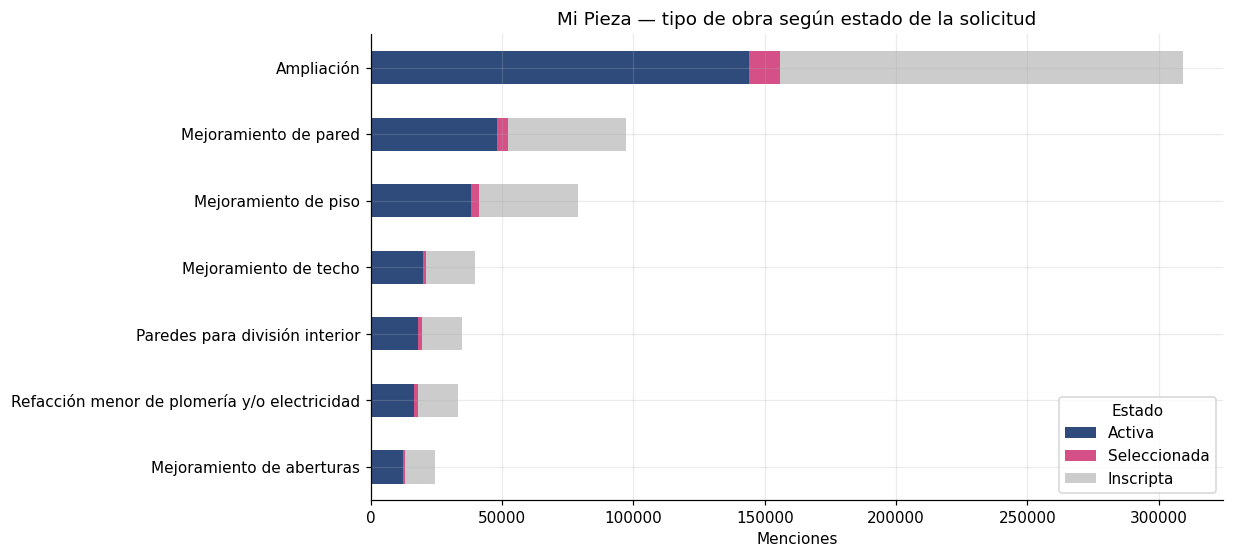

In [19]:
# --- Gráfico: tipo de obra por estado ------------------------------------
top_tipos = tipo_x_estado.drop(index="Total", errors="ignore").head(10)
cols = [c for c in ["Activa", "Seleccionada", "Inscripta"] if c in top_tipos.columns]
ax = top_tipos[cols].iloc[::-1].plot(kind="barh", stacked=True,
                                     color=[PAL[0], PAL[2], "#CCCCCC"])
ax.set_title("Mi Pieza — tipo de obra según estado de la solicitud")
ax.set_xlabel("Menciones"); ax.set_ylabel("")
ax.legend(title="Estado")
guardar_fig("03_mipieza_tipo_estado")
plt.show()

In [20]:
# --- 3.5 Mi Pieza (monitor barrial) ---------------------------------------
mpm = mipieza_mon.copy()
mpm.columns = [c.strip() for c in mpm.columns]
mpm = mpm.rename(columns={
    "Provincia": "provincia", "Municipio": "municipio",
    "ID RENABAP": "id_renabap_raw", "Barrio": "barrio",
    "Obras no iniciadas": "obras_no_iniciadas",
    "Obras en ejecución": "obras_en_ejecucion",
    "Obras terminadas": "obras_terminadas",
    "Adjudicaciones rechazadas": "adjudicaciones_rechazadas",
    "Inversión total": "inversion_total",
})
for c in ["obras_no_iniciadas", "obras_en_ejecucion", "obras_terminadas",
          "adjudicaciones_rechazadas", "inversion_total"]:
    mpm[c] = mpm[c].map(a_numero)

mpm["obras_total"] = mpm[["obras_no_iniciadas", "obras_en_ejecucion", "obras_terminadas"]].sum(axis=1)
mpm["provincia_norm"] = mpm["provincia"].map(norm_texto)
mpm["ids_renabap"]   = mpm["id_renabap_raw"].map(ids_renabap)
mpm["id_provisorio"] = mpm["id_renabap_raw"].map(id_provisorio)
print(f"Registros con identificador provisorio (asterisco): {mpm['id_provisorio'].sum()}")

mipieza_mon = mpm
mipieza_mon_barrio = (mipieza_mon.explode("ids_renabap")
                                 .rename(columns={"ids_renabap": "id_renabap"}))
mipieza_mon_barrio = mipieza_mon_barrio[mipieza_mon_barrio["id_renabap"].notna()].copy()
print(mipieza_mon.shape, mipieza_mon_barrio.shape)
mipieza_mon.head(3)

Registros con identificador provisorio (asterisco): 34
(5051, 13) (5051, 13)


,provincia,municipio,id_renabap_raw,barrio,obras_no_iniciadas,obras_en_ejecucion,obras_terminadas,adjudicaciones_rechazadas,inversion_total,obras_total,provincia_norm,ids_renabap,id_provisorio
0,Buenos Aires,Lomas de Zamora,25,Laberinto,0.00,1.00,6.00,2.00,"2,740,000.00",7.00,buenos aires,[25],False
1,Buenos Aires,La Plata,46,Sin Nombre,0.00,3.00,68.00,7.00,"24,260,000.00",71.00,buenos aires,[46],False
2,Buenos Aires,Esteban Echeverría,785,El Gauchito Gil,0.00,6.00,61.00,5.00,"26,710,000.00",67.00,buenos aires,[785],False


---
### 3.6 Deflación — Índice del Costo de la Construcción (ICC, INDEC)

Los montos se conservan **a precios corrientes** como valor de referencia principal, y se agrega en paralelo una columna a **precios constantes** deflactada por el ICC nivel general del INDEC (Gran Buenos Aires, base 1993 = 100).

La serie se carga desde el propio repositorio (`data/raw/indice_icc.csv`), lo que hace el cuaderno reproducible sin depender de que el portal del INDEC responda.

**El archivo trae variaciones porcentuales mensuales, no niveles de índice.** No se puede deflactar directamente con esa columna: hay que reconstruir el índice encadenando las variaciones. La base de arranque es arbitraria —acá 100 en el primer mes disponible— porque la deflación trabaja con cocientes entre dos meses, y cualquier base se cancela en la división.

El archivo está en formato largo, con cuatro aperturas por mes: nivel general, materiales, mano de obra y gastos generales. Se usa el nivel general para el cálculo principal y las otras tres quedan disponibles para el análisis de sensibilidad de la celda siguiente.

Dos advertencias que conviene declarar en la tesis:

- El ICC mide costos de construcción privada de vivienda en el Gran Buenos Aires. Es el deflactor estándar para obra pública en Argentina, pero **no capta diferenciales regionales de costo**: aplicado a Tucumán es una aproximación.
- La fecha usada para deflactar es el **acta de inicio real**, no la de contratación ni la de certificación. Los proyectos sin acta informada quedan sin monto constante.

In [21]:
# --- Carga de la serie ICC -----------------------------------------------
# Formato del archivo: separador ';', decimal ',', fecha d/m/aaaa,
# estructura larga (una fila por mes y apertura), valores en variación % mensual.
MES_BASE_ICC = "2023-12"   # mes al que se llevan todos los montos

icc_crudo = pd.read_csv(f"{RAW}/indice_icc.csv", sep=";", decimal=",")
icc_crudo["fecha"] = pd.to_datetime(icc_crudo["periodo"], format="%d/%m/%Y", errors="coerce")
icc_crudo["periodo_m"] = icc_crudo["fecha"].dt.to_period("M").astype(str)

print("Aperturas disponibles:", icc_crudo["nivel_general_aperturas"].unique().tolist())
print(f"Cobertura: {icc_crudo['periodo_m'].min()} a {icc_crudo['periodo_m'].max()} "
      f"({icc_crudo['periodo_m'].nunique()} meses)")
print(f"Nulos en la variación: {icc_crudo['variacion_indice_icc'].isna().sum()}")
icc_crudo.head()

Aperturas disponibles: ['nivel_general', 'materiales', 'mano_de_obra', 'gastos_generales']
Cobertura: 2015-11 a 2026-07 (129 meses)
Nulos en la variación: 0


,periodo,nivel_general_aperturas,variacion_indice_icc,fecha,periodo_m
0,1/11/2015,nivel_general,0.85,2015-11-01,2015-11
1,1/11/2015,materiales,2.03,2015-11-01,2015-11
2,1/11/2015,mano_de_obra,0.15,2015-11-01,2015-11
3,1/11/2015,gastos_generales,0.50,2015-11-01,2015-11
4,1/12/2015,nivel_general,2.80,2015-12-01,2015-12


In [22]:
# --- Reconstrucción del índice a partir de las variaciones ---------------
def encadenar(variaciones, base=100.0):
    '''Convierte una serie de variaciones % mensuales en un índice encadenado.'''
    return base * (1 + variaciones / 100).cumprod()


ICC = (icc_crudo
       .sort_values("fecha")
       .pivot_table(index="periodo_m", columns="nivel_general_aperturas",
                    values="variacion_indice_icc", aggfunc="first")
       .sort_index())

# Verificación: no puede haber meses faltantes en el medio, porque el
# encadenamiento arrastraría el hueco a toda la serie posterior.
esperados = pd.period_range(ICC.index.min(), ICC.index.max(), freq="M").astype(str)
faltantes = set(esperados) - set(ICC.index)
print(f"Meses faltantes en la serie: {len(faltantes)}"
      + (f" -> {sorted(faltantes)}" if faltantes else " (serie continua)"))

for col in ICC.columns:
    ICC[f"idx_{col}"] = encadenar(ICC[col])

ICC = ICC.reset_index().rename(columns={"idx_nivel_general": "icc"})
print(f"\nÍndice reconstruido: {len(ICC)} meses")
ICC[["periodo_m", "nivel_general", "icc", "idx_materiales", "idx_mano_de_obra"]].tail(6)

Meses faltantes en la serie: 0 (serie continua)

Índice reconstruido: 129 meses


nivel_general_aperturas,periodo_m,nivel_general,icc,idx_materiales,idx_mano_de_obra
123,2026-02,2.01,"12,734.59","14,983.26","10,826.88"
124,2026-03,1.94,"12,982.07","15,249.51","11,061.08"
125,2026-04,3.93,"13,491.66","15,699.06","11,603.23"
126,2026-05,2.75,"13,862.33","15,944.63","12,016.53"
127,2026-06,2.62,"14,225.81","16,233.68","12,410.63"
128,2026-07,2.11,"14,525.91","16,490.79","12,715.39"


In [23]:
# --- Validación contra las cifras publicadas por el INDEC ----------------
# Si el encadenamiento está bien hecho, las variaciones derivadas del índice
# reconstruido deben coincidir con las que publica el informe de prensa.
s = ICC.set_index("periodo_m")["icc"]

def var_pct(desde, hasta):
    if desde in s.index and hasta in s.index:
        return round((s[hasta] / s[desde] - 1) * 100, 1)
    return np.nan

controles = pd.DataFrame([
    {"control": "Var. interanual jun-2026", "reconstruido": var_pct("2025-06", "2026-06"),
     "publicado_INDEC": 32.1},
    {"control": "Var. acumulada 2026 a jun", "reconstruido": var_pct("2025-12", "2026-06"),
     "publicado_INDEC": 16.7},
    {"control": "Var. mensual jun-2026", "reconstruido": var_pct("2026-05", "2026-06"),
     "publicado_INDEC": 2.6},
])
controles["diferencia"] = (controles["reconstruido"] - controles["publicado_INDEC"]).round(1)
guardar_tabla(controles.set_index("control"), "03_validacion_icc")

print("Fuente de los valores publicados: INDEC, informe técnico ICC junio de 2026.")
print("Diferencias de una décima corresponden a redondeo, no a error de método.\n")
controles

Fuente de los valores publicados: INDEC, informe técnico ICC junio de 2026.
Diferencias de una décima corresponden a redondeo, no a error de método.



,control,reconstruido,publicado_INDEC,diferencia
0,Var. interanual jun-2026,32.20,32.10,0.10
1,Var. acumulada 2026 a jun,16.80,16.70,0.10
2,Var. mensual jun-2026,2.60,2.60,0.00


In [24]:
# --- Aplicación del deflactor --------------------------------------------
obras["periodo_inicio"] = obras["acta_inicio"].dt.to_period("M").astype(str)
obras.loc[obras["acta_inicio"].isna(), "periodo_inicio"] = np.nan

icc_map = dict(zip(ICC["periodo_m"], ICC["icc"]))

if MES_BASE_ICC not in icc_map:
    MES_BASE_ICC = ICC["periodo_m"].max()
    print(f"Mes base fuera de la serie; se usa el último disponible: {MES_BASE_ICC}")
icc_base = icc_map[MES_BASE_ICC]

obras["icc_inicio"] = obras["periodo_inicio"].map(icc_map)
obras["monto_constante"] = obras["monto_total"] * (icc_base / obras["icc_inicio"])

n_ok = obras["monto_constante"].notna().sum()
sin_acta = obras["acta_inicio"].isna().sum()
fuera_rango = ((obras["periodo_inicio"].notna()) & (obras["icc_inicio"].isna())).sum()

print(f"Montos deflactados a precios de {MES_BASE_ICC}: {n_ok} de {len(obras)} "
      f"({n_ok/len(obras)*100:.1f} %)")
print(f"  sin acta de inicio informada        : {sin_acta}")
print(f"  con acta fuera del rango de la serie: {fuera_rango}")
print(f"\nTotal corriente : $ {obras['monto_total'].sum():,.0f} (todos los proyectos)")
print(f"Total constante : $ {obras['monto_constante'].sum():,.0f} "
      f"(sólo los {n_ok} con acta)")
print(f"Total corriente de esos mismos {n_ok}: "
      f"$ {obras.loc[obras['monto_constante'].notna(), 'monto_total'].sum():,.0f}")

obras[["proyecto_id", "acta_inicio", "periodo_inicio", "monto_total",
       "icc_inicio", "monto_constante"]].head()

Montos deflactados a precios de 2023-12: 1227 de 1315 (93.3 %)
  sin acta de inicio informada        : 88
  con acta fuera del rango de la serie: 0

Total corriente : $ 570,179,849,167 (todos los proyectos)
Total constante : $ 1,272,254,117,178 (sólo los 1227 con acta)
Total corriente de esos mismos 1227: $ 529,524,864,441


,proyecto_id,acta_inicio,periodo_inicio,monto_total,icc_inicio,monto_constante
0,P00000,2024-04-15,2024-04,"269,219,376.83","7,186.06","193,043,693.77"
1,P00001,2023-12-01,2023-12,"186,308,259.30","5,152.76","186,308,259.30"
2,P00002,2023-12-15,2023-12,"181,540,041.99","5,152.76","181,540,041.99"
3,P00003,2023-09-22,2023-09,"1,273,196,907.29","3,300.70","1,987,604,223.71"
4,P00004,2023-09-29,2023-09,"29,355,856.79","3,300.70","45,827,809.20"


La última comparación importa: el total constante debe contrastarse contra el corriente **del mismo subconjunto**, no contra el total general. Comparar 1.315 proyectos corrientes con los que tienen acta informada mezcla el efecto del deflactor con el de la cobertura del dato.

In [25]:
# --- Sensibilidad: ¿cambia el resultado según la apertura del ICC? -------
# Las obras de integración son más intensivas en materiales y movimiento de
# suelo que la vivienda privada que modela el ICC. Deflactar por "materiales"
# y por "mano de obra" acota cuánto depende el resultado de esa elección.
aperturas = {"Nivel general": "icc",
             "Materiales": "idx_materiales",
             "Mano de obra": "idx_mano_de_obra",
             "Gastos generales": "idx_gastos_generales"}

sens = {}
for etiqueta, col in aperturas.items():
    if col not in ICC.columns:
        continue
    m = dict(zip(ICC["periodo_m"], ICC[col]))
    base = m[MES_BASE_ICC]
    sens[etiqueta] = (obras["monto_total"] * (base / obras["periodo_inicio"].map(m))).sum()

sensibilidad = pd.Series(sens, name=f"Total a precios de {MES_BASE_ICC}").to_frame()
sensibilidad["desvío vs. nivel general (%)"] = (
    (sensibilidad.iloc[:, 0] / sensibilidad.iloc[0, 0] - 1) * 100).round(1)
guardar_tabla(sensibilidad, "03_sensibilidad_deflactor")
sensibilidad

,Total a precios de 2023-12,desvío vs. nivel general (%)
Nivel general,"1,272,254,117,178.09",0.00
Materiales,"1,540,010,521,588.07",21.00
Mano de obra,"1,024,499,793,919.52",-19.50
Gastos generales,"1,137,450,218,662.36",-10.60


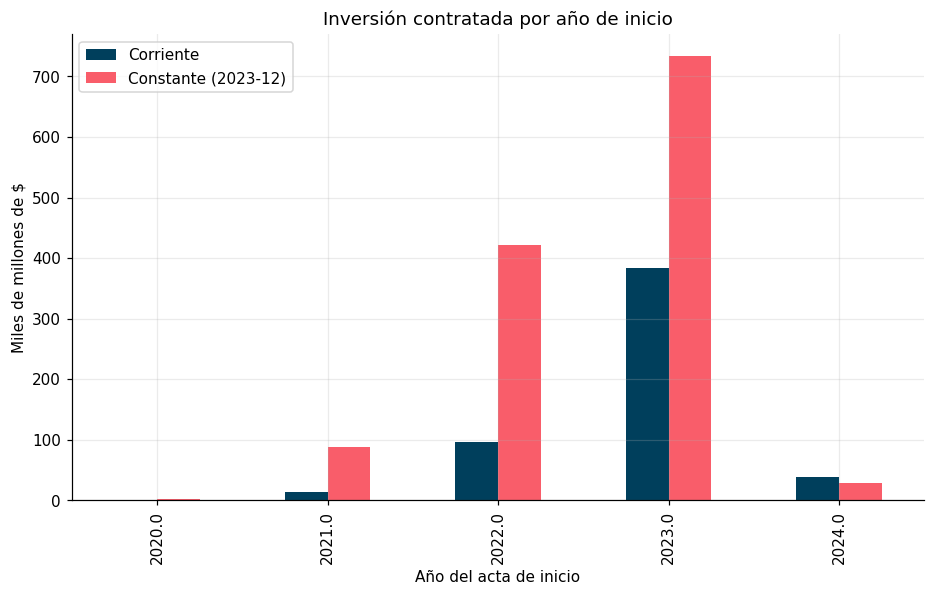

,Corriente,Constante (2023-12)
anio_inicio,,
"2,020.00",0.23,2.43
"2,021.00",12.96,87.85
"2,022.00",96.24,420.81
"2,023.00",382.76,733.20
"2,024.00",37.34,27.96


In [26]:
# Comparación corriente vs. constante por año de inicio
if obras["monto_constante"].notna().any():
    por_anio = (obras.dropna(subset=["anio_inicio"])
                     .groupby("anio_inicio")[["monto_total", "monto_constante"]]
                     .sum() / 1e9)
    por_anio.columns = ["Corriente", f"Constante ({MES_BASE_ICC})"]
    guardar_tabla(por_anio, "03_montos_corriente_vs_constante")

    ax = por_anio.plot(kind="bar", color=[PAL[7], PAL[3]])
    ax.set_title("Inversión contratada por año de inicio")
    ax.set_ylabel("Miles de millones de $"); ax.set_xlabel("Año del acta de inicio")
    guardar_fig("03_deflacion")
    plt.show()
    display(por_anio)

---
## 4. Esquema de clasificación F3 — tipo, dimensión y escala

Este es el núcleo del bloque. Cada proyecto se clasifica en tres capas encadenadas:

| Capa | Contenido | Origen |
|---|---|---|
| **Tipo** | Ocho ejes de intervención | construidos sobre el vocabulario efectivo de las bases |
| **Dimensión** | Infraestructuras · Equipamiento · Calidad ambiental · Situación dominial, con sus subdimensiones | matrices del Capítulo II |
| **Escala** | Barrial · Comunitaria | operacionalización del Capítulo II |

Cuatro decisiones metodológicas incorporadas:

1. **Clasificación multietiqueta.** Los nombres de proyecto enumeran componentes (`"Red de agua, Red cloacal y Conexiones domiciliarias"`), de modo que un proyecto puede activar varios tipos y varias dimensiones. Se conservan las columnas booleanas completas y se agrega un `tipo_principal` / `dimension_principal` para los cruces que exigen categoría única.

2. **Categoría "sin especificar".** Los proyectos cuyo nombre es una variante genérica de "Obras de Integración Socio Urbana" se identifican **antes** de la clasificación y quedan fuera de ella. No es una falla del clasificador: es la fuente la que no declara componentes. Son ~15% de los proyectos y su peso debe reportarse como límite de la base.

3. **Tipo y dimensión se clasifican por separado** y después se contrastan. Si fueran una simple traducción del tipo, la dimensión no aportaría información; corriéndolos en paralelo, la tabla de coherencia muestra dónde el vocabulario de la fuente y las matrices del Capítulo II no se superponen.

4. **La escala es la capa más frágil.** El nombre de un proyecto casi nunca dice si la obra es intrabarrial o de conexión con el entorno: `"Red de agua"` puede ser una red interna o un nexo. Se asigna una escala por defecto según subdimensión, se corrige con un diccionario de expresiones que sí son diagnósticas (`nexo`, `extensión de red`, `intralote`, `conexiones domiciliarias`), y **todo proyecto cuya escala no haya sido confirmada por una de esas expresiones queda marcado en `escala_verificar = True`**. Esa columna es la lista de trabajo para el cotejo con expedientes, entrevistas o imagen satelital.

---

**Una tensión que conviene resolver antes de escribir.** Las cuatro dimensiones del Capítulo II no incluyen *vivienda*, pero una parte sustantiva de lo ejecutado son núcleos húmedos, mejoramientos y —sobre todo— Mi Pieza, que es íntegramente mejoramiento habitacional. En el esquema quedan bajo la etiqueta provisoria `Vivienda (fuera de matriz)` para que sean visibles en las tablas en lugar de desaparecer. Hay dos salidas posibles: incorporarlas a "Entorno y vivienda" recuperando la formulación de la dimensión secundaria, o declarar explícitamente que las matrices operacionalizan el entorno y no la unidad habitacional. La segunda opción es defendible, pero deja a Mi Pieza sin lugar en la matriz siendo la línea de mayor cobertura territorial.

In [1070]:
# =============================================================
#  CAPA 1 — TIPO DE INTERVENCIÓN (nueve ejes)
# =============================================================
EJES = {
    "infraestructura_servicios": [
        r"red de agua", r"agua potable", r"\bcloac", r"red cloacal", r"desagu", r"pluvial",
        r"electric", r"energia electrica", r"red de distribucion",
        r"\bgas\b", r"tendido", r"agua", r"estacion de bombeo", r"electrificacion",
    ],
    "conexiones_intradomiciliarias": [
        r"intra ?lote", r"intra ?domiciliar", r"conexiones domiciliar",
        r"conexiones e instalaciones", r"instalaciones intra", r"nexo",
    ],
    "movilidad_accesibilidad": [
        r"vereda", r"cordon cuneta", r"red peatonal", r"peatonal", r"red vial",
        r"pavimen", r"calzada", r"puente", r"escalera", r"senda", r"alumbrado",  r"via publica", r"pasillos", r"pasaje", r"iluminacion", r"calles", r"luminarias", r"pavimento",
    ],
    "ambiente": [
        r"residuos", r"ambiental",
        r"centro verde", r"ecopunto", r"punto verde", r"defensa", r"encauzamiento",
        r"canal", r"mitigacion", r"saneamiento ambiental", r"planta de separacion", r"basural", r"hidraulicas", r"centro de acopio", r"cauce", r"saneamiento hidraulico", r"accesibilidad",
    ],
    "espacio_publico": [
        r"plaza", r"playon", r"espacio publico", r"espacio recreativo", r"recreativ",
        r"deportiv", r"arbolado", r"forestac", r"parquizac",
      ],
    "equipamiento_comunitario": [
        r"equipamiento", r"centro comunitario", r"centro barrial", r"\bsum\b",
        r"salon de usos", r"salud", r"cepla", r"jardin", r"educativ", r"comedor",
        r"posta", r"casa convivencial", r"espacio comunitario", r"espacios urbanos", r"memorial",
    ],
    "vivienda": [
        r"vivienda", r"nucleo(s)? humedo", r"mejora(miento)? de vivienda",
        r"refaccion", r"relocalizacion", r"modulo habitacional", r"\bmv\b",
    ],
    "suelo_regularizacion": [
        r"\blote", r"adquisicion de tierra", r"tierra privada", r"mensura",
        r"loteo", r"dominial", r"redimensionamiento",
    ],
    "planificacion_proyecto": [
        r"proyecto ejecutivo", r"\bpre ?peg\b", r"diseno de un proyecto",
        r"diseno de proyecto", r"proyecto integral", r"plan de", r"estudio", r"anteproyecto",
    ],
}

EJES_ETIQUETA = {
    "infraestructura_servicios":     "Infraestructura de servicios",
    "conexiones_intradomiciliarias": "Conexiones intradomiciliarias",
    "movilidad_accesibilidad":       "Movilidad y accesibilidad",
    "ambiente":                      "Ambiente",
    "espacio_publico":               "Espacio público",
    "equipamiento_comunitario":      "Equipamiento comunitario",
    "vivienda":                      "Vivienda",
    "suelo_regularizacion":          "Suelo y regularización",
    "planificacion_proyecto":        "Planificación / proyecto",
}

# Nombres genéricos que no declaran componentes -> categoría propia
PATRONES_GENERICOS = [
    r"^obras? de integracion socio ?-? ?urbanas?\.?$",
    r"^obras? de integracion sociourbanas?\.?$",
    r"^proyecto de integracion socio ?-? ?urbana$",
    r"^obras? de integracion urbana$",
    r"^obras? de interacion socio urbana$",
    r"^obras? de integracion socio urbanas? \(?etapa \d\)?$",
    r"^obras? de integracion socio urbana -?$",
]

In [1121]:
# =============================================================
#  CAPA 2 — DIMENSIÓN Y SUBDIMENSIÓN (matrices del Capítulo II)
# =============================================================
SUBDIMENSIONES = {
    "movilidad_conectividad": {
        "dimension": "Infraestructuras",
        "etiqueta": "Movilidad y conectividad",
        "escala_defecto": "barrial",
        "patrones": [r"vereda", r"cordon cuneta", r"red peatonal", r"peatonal",
                     r"red vial", r"pavimen", r"calzada", r"puente", r"escalera", r"pavimento",
                     r"senda", r"apertura de calle", r"alumbrado", r"luminaria", r"via publica", r"pasillos", r"pasaje",r"iluminacion", r"calles", r"luminarias", r"accesibilidad",],
    },
    "servicios_basicos_energia": {
        "dimension": "Infraestructuras",
        "etiqueta": "Servicios básicos y energía",
        "escala_defecto": "barrial",
        "patrones": [r"red de agua", r"agua potable", r"\bcloac", r"desagu", r"pluvial", r"nexo", r"red cloacal", r"energia electrica" , r"agua",
                    r"sanitari",r"\bgas\b",r"electric", r"red de distribucion", r"intra ?lote", r"intra ?domiciliar",
                     r"conexiones domiciliar", r"conexiones e instalaciones", r"instalaciones intra",
                    r"tendido electric", r"estacion de bombeo", r"agua", r"electrificacion",r"tendido", ]
    },
    "espacio_publico_deporte_cultura": {
        "dimension": "Equipamiento",
        "etiqueta": "Espacio público, deporte y cultura",
        "escala_defecto": "comunitaria",
        "patrones": [r"plaza", r"playon", r"espacio publico", r"espacio recreativo", r"arbolado", r"forestac", r"parquizac", r"parque",r"plazoleta",
                     r"recreativ", r"deportiv", r"cultural",  r"memorial",],
    },
    "salud_educacion": {
        "dimension": "Equipamiento",
        "etiqueta": "Salud y educación",
        "escala_defecto": "comunitaria",
        "patrones": [r"salud", r"cepla", r"jardin", r"educativ", r"escuela", r"posta",
                     r"centro de atencion primaria", r"\bcaps\b",],
    },
    "administracion_bienestar": {
        "dimension": "Equipamiento",
        "etiqueta": "Administración y bienestar",
        "escala_defecto": "comunitaria",
        "patrones": [r"centro comunitario", r"centro barrial", r"comedor",
                     r"casa convivencial", r"bienestar", r"desarrollo social", r"\bsum\b", r"salon de usos", r"espacio comunitario", r"espacios urbanos", r"equipamiento",],
    },
    "servicios_consumo": {
        "dimension": "Equipamiento",
        "etiqueta": "Servicios y consumo",
        "escala_defecto": "comunitaria",
        "patrones": [r"mercado", r"\bferia\b", r"comercial", r"productiv",
                     r"polo\b", r"vivero", ],
    },

    "ambiental": {
        "dimension": "Calidad ambiental",
        "etiqueta": "Condiciones ambientales",
        "escala_defecto": "comunitaria",
        "patrones": [ r"residuos", r"ambiental", r"defensa", r"encauzamiento", r"canal", r"mitigacion",
                     r"saneamiento ambiental", r"planta de separacion", r"basural",
                     r"ecopunto", r"punto verde", r"centro verde", r"centro de acopio", r"cauce", r"hidraulicas", r"saneamiento hidraulico",],
    },

    "regularizacion_tenencia": {
        "dimension": "Situación dominial",
        "etiqueta": "Regularización y seguridad en la tenencia",
        "escala_defecto": "barrial",
        "patrones": [r"\blote", r"adquisicion de tierra", r"tierra privada", r"mensura",
                     r"loteo", r"dominial", r"redimensionamiento", r"regularizacion", ],
    },
    "mejoramiento_vivienda": {
        "dimension": "Vivienda",
        "etiqueta": "Mejoramiento y provisión de vivienda",
        "escala_defecto": "barrial",
        "patrones": [r"vivienda", r"mejora(miento)? de vivienda", r"refaccion", r"modulo habitacional",
                     r"\bmv\b", r"nucleo(s)? humedo",
                     r"refaccion", r"modulo habitacional", r"\bmv\b", r"relocalizacion" ],
    },
    "instrumento_planificacion": {
        "dimension": "Planificación",
        "etiqueta": "Planificación y proyecto",
        "escala_defecto": "comunitaria",
        "patrones": [r"proyecto ejecutivo", r"\bpre ?peg\b", r"diseno de un proyecto",
                     r"diseno de proyecto", r"proyecto integral", r"anteproyecto",
                     r"plan de", r"estudio", ],
    },
}

DIMENSIONES = ["Infraestructuras", "Equipamiento", "Calidad ambiental",
               "Situación dominial", "Vivienda"]


# =============================================================
#  CAPA 3 — ESCALA: expresiones diagnósticas
# =============================================================
ESCALA_COMUNITARIA = [
    r"\bnexo", r"extension de red", r"conexion a la red troncal", r"troncal",
    r"colectora", r"planta de", r"centro verde", r"adquisicion de tierra",
    r"tierra privada", r"defensa", r"canal", r"puente", r"red vial",
    r"cepla", r"centro de atencion primaria", r"acceso al barrio",
]
ESCALA_BARRIAL = [
    r"intra ?lote", r"intra ?domiciliar", r"conexiones domiciliar", r"nucleo(s)? humedo",
    r"vivienda", r"vereda", r"mejora(miento)? de vivienda", r"refaccion",
    r"cordon cuneta", r"red peatonal interna",
]

In [1122]:
def clasificar_f3(serie_texto):
    '''Clasifica en tipo, dimensión/subdimensión y escala. Devuelve un DataFrame.'''
    txt = serie_texto.map(norm_texto).fillna("")
    out = pd.DataFrame(index=serie_texto.index)

    # --- genéricos ---
    generico = txt.str.match("|".join(PATRONES_GENERICOS), na=False)
    out["sin_especificar"] = generico

    # --- capa 1: tipo ---
    for eje, patrones in EJES.items():
        out[f"eje_{eje}"] = txt.str.contains("|".join(patrones), regex=True, na=False) & ~generico
    cols_eje = [f"eje_{e}" for e in EJES]
    out["n_ejes"] = out[cols_eje].sum(axis=1)

    def _principal(fila, claves, prefijo, etiqueta_generica):
        if fila["sin_especificar"]:
            return etiqueta_generica
        for k in claves:
            if fila[f"{prefijo}{k}"]:
                return k
        return "sin_clasificar"

    out["eje_principal"] = out.apply(
        lambda f: _principal(f, list(EJES), "eje_", "sin_especificar"), axis=1)

    # --- capa 2: subdimensión y dimensión ---
    for sub, cfg in SUBDIMENSIONES.items():
        out[f"sub_{sub}"] = txt.str.contains("|".join(cfg["patrones"]), regex=True, na=False) & ~generico
    cols_sub = [f"sub_{s}" for s in SUBDIMENSIONES]
    out["n_subdimensiones"] = out[cols_sub].sum(axis=1)

    for dim in DIMENSIONES:
        subs = [s for s, c in SUBDIMENSIONES.items() if c["dimension"] == dim]
        out[f"dim_{dim}"] = out[[f"sub_{s}" for s in subs]].any(axis=1)
    cols_dim = [f"dim_{d}" for d in DIMENSIONES]
    out["n_dimensiones"] = out[cols_dim].sum(axis=1)

    out["subdimension_principal"] = out.apply(
        lambda f: _principal(f, list(SUBDIMENSIONES), "sub_", "sin_especificar"), axis=1)
    out["dimension_principal"] = out["subdimension_principal"].map(
        lambda s: SUBDIMENSIONES[s]["dimension"] if s in SUBDIMENSIONES
        else ("Sin especificar" if s == "sin_especificar" else "Sin clasificar"))

    # --- capa 3: escala ---
    fuerza_com = txt.str.contains("|".join(ESCALA_COMUNITARIA), regex=True, na=False)
    fuerza_bar = txt.str.contains("|".join(ESCALA_BARRIAL), regex=True, na=False)

    def _escala(i):
        if out.at[i, "sin_especificar"]:
            return "sin determinar", True
        if fuerza_com[i] and fuerza_bar[i]:
            return "ambas", False
        if fuerza_com[i]:
            return "comunitaria", False
        if fuerza_bar[i]:
            return "barrial", False
        # sin expresión diagnóstica: se usa el valor por defecto de las subdimensiones
        defectos = {SUBDIMENSIONES[s]["escala_defecto"]
                    for s in SUBDIMENSIONES if out.at[i, f"sub_{s}"]}
        defectos.discard("sin determinar")
        if not defectos:
            return "sin determinar", True
        if len(defectos) > 1:
            return "ambas", True
        return defectos.pop(), True

    res = [_escala(i) for i in out.index]
    out["escala"] = [r[0] for r in res]
    out["escala_verificar"] = [r[1] for r in res]
    return out


def aplicar_f3(df, col_texto):
    nuevas = clasificar_f3(df[col_texto])
    viejas = [c for c in df.columns if c.startswith(("eje_", "sub_", "dim_"))
              or c in ("n_ejes", "n_subdimensiones", "n_dimensiones", "eje_principal",
                       "subdimension_principal", "dimension_principal", "escala",
                       "escala_verificar", "sin_especificar")]
    return pd.concat([df.drop(columns=viejas, errors="ignore"), nuevas], axis=1)


obras   = aplicar_f3(obras, "nombre_proyecto")
monitor = aplicar_f3(monitor, "nombre_obra")


# =============================================================
#  PASADAS COMPLEMENTARIAS
# =============================================================
# El nombre del proyecto no siempre alcanza. Se agregan dos pasadas y se deja
# registro de cómo se clasificó cada proyecto en la columna `origen_clasificacion`.

# Pasada 2 — genéricos no anclados: el nombre invoca la política sin declarar
# componentes ("Obras de Integración Socio Urbana - Barrio San Jacinto").
GENERICO_AMPLIO = r"integracion soci|integracion urbana|obras de infraestructura$|infraestructura urbana"

# Pasada 3 — imputación por línea programática. Cuando el nombre no dice nada
# pero la línea sí: MV es mejoramiento de vivienda, LOTES es suelo, PEG/PrePEG
# son instrumentos de planificación. POT no informa contenido y no se imputa.
LINEA_A_CLASIFICACION = {
    "MV":             ("vivienda", "mejoramiento_vivienda"),
    "VIVIENDA":       ("vivienda", "mejoramiento_vivienda"),
    "LOTES":          ("suelo_regularizacion", "regularizacion_tenencia"),
    "LOTES (Adq.)":   ("suelo_regularizacion", "regularizacion_tenencia"),
    "PEG":            ("planificacion_proyecto", "instrumento_planificacion"),
    "PrePEG":         ("planificacion_proyecto", "instrumento_planificacion"),
    "INTEGRAR SALUD": ("equipamiento_comunitario", "salud_educacion"),
}


def completar_clasificacion(df, col_linea="linea_programatica"):
    d = df.copy()
    d["origen_clasificacion"] = np.where(
        d["sin_especificar"], "genérico",
        np.where(d["eje_principal"] == "sin_clasificar", "sin clasificar", "nombre"))

    txt = d["nombre_proyecto"].map(norm_texto).fillna("") if "nombre_proyecto" in d \
          else d["nombre_obra"].map(norm_texto).fillna("")

    # Pasada 2
    m2 = (d["eje_principal"] == "sin_clasificar") & txt.str.contains(GENERICO_AMPLIO, na=False)
    d.loc[m2, "sin_especificar"] = True
    d.loc[m2, "eje_principal"] = "sin_especificar"
    d.loc[m2, "subdimension_principal"] = "sin_especificar"
    d.loc[m2, "dimension_principal"] = "Sin especificar"
    d.loc[m2, "escala"] = "sin determinar"
    d.loc[m2, "escala_verificar"] = True
    d.loc[m2, "origen_clasificacion"] = "genérico"

    # Pasada 3
    if col_linea in d.columns:
        sin_info = d["eje_principal"].isin(["sin_clasificar", "sin_especificar"])
        for linea, (eje, sub) in LINEA_A_CLASIFICACION.items():
            m3 = sin_info & (d[col_linea] == linea)
            if not m3.any():
                continue
            d.loc[m3, f"eje_{eje}"] = True
            d.loc[m3, f"sub_{sub}"] = True
            d.loc[m3, f"dim_{SUBDIMENSIONES[sub]['dimension']}"] = True
            d.loc[m3, "eje_principal"] = eje
            d.loc[m3, "subdimension_principal"] = sub
            d.loc[m3, "dimension_principal"] = SUBDIMENSIONES[sub]["dimension"]
            d.loc[m3, "escala"] = SUBDIMENSIONES[sub]["escala_defecto"]
            d.loc[m3, "escala_verificar"] = True
            d.loc[m3, "sin_especificar"] = False
            d.loc[m3, "origen_clasificacion"] = "línea programática"

    d["n_ejes"] = d[[f"eje_{e}" for e in EJES]].sum(axis=1)
    d["n_subdimensiones"] = d[[f"sub_{x}" for x in SUBDIMENSIONES]].sum(axis=1)
    d["n_dimensiones"] = d[[f"dim_{x}" for x in DIMENSIONES]].sum(axis=1)
    return d


obras = completar_clasificacion(obras)

print("Origen de la clasificación de cada proyecto:")
print(obras["origen_clasificacion"].value_counts().to_string())

# --- Nombres de municipio que designan la misma jurisdicción -------------
# "Lules" y "San Isidro de Lules" son la misma Municipalidad de San Isidro de
# Lules; las bases nacionales alternan ambas formas.
EQUIVALENCIAS_MUNICIPIO = {
    "lules": "san isidro de lules",
    "san isidro de lules": "san isidro de lules",
}

def unificar_municipio(m):
    return EQUIVALENCIAS_MUNICIPIO.get(m, m)

obras["municipio_amt"]   = obras["municipio_norm"].map(unificar_municipio)
monitor["municipio_amt"] = monitor["municipio_norm"].map(unificar_municipio)

# --- Reconstrucción de las tablas por barrio con la clasificación F3 -----
def explotar(df, col_id="ids_renabap"):
    d = df.explode(col_id).rename(columns={col_id: "id_renabap"})
    d = d[d["id_renabap"].notna()].copy()
    d["id_renabap"] = d["id_renabap"].astype(str)
    return d

obras_barrio       = explotar(obras)
monitor_barrio     = explotar(monitor)
mipieza_mon_barrio = explotar(mipieza_mon)

print(f"Proyectos totales          : {len(obras)}")
print(f"Genéricos (sin especificar): {obras['sin_especificar'].sum()} "
      f"({obras['sin_especificar'].mean()*100:.1f} %)")
print(f"Sin clasificar por tipo    : {(obras['eje_principal'] == 'sin_clasificar').sum()}")
print(f"Sin clasificar por dimensión: {(obras['dimension_principal'] == 'Sin clasificar').sum()}")

Origen de la clasificación de cada proyecto:
origen_clasificacion
nombre                1160
genérico                79
línea programática      53
sin clasificar          23
Proyectos totales          : 1315
Genéricos (sin especificar): 79 (6.0 %)
Sin clasificar por tipo    : 23
Sin clasificar por dimensión: 22


In [1123]:
# --- Carácter de la intervención (atributo, no dimensión) ---------------
# Planificación no es una dimensión territorial: no produce transformación,
# produce un documento. Se registra como atributo del proyecto, ortogonal a
# la dimensión, para poder separar obra de proyecto sin inflar la cobertura.
EJES_OBRA = [e for e in EJES if e != "planificacion_proyecto"]

obras["caracter_intervencion"] = np.where(
    obras["eje_planificacion_proyecto"] & ~obras[[f"eje_{e}" for e in EJES_OBRA]].any(axis=1),
    "proyecto / estudio", "obra")

print(obras["caracter_intervencion"].value_counts().to_string())
print()
print(pd.crosstab(obras["linea_programatica"], obras["caracter_intervencion"]))

caracter_intervencion
obra                  1260
proyecto / estudio      55

caracter_intervencion  obra  proyecto / estudio
linea_programatica                             
INTEGRAR SALUD           20                   0
LOTES                   106                   0
LOTES (Adq.)             15                   0
MV                       21                   0
PEG                      25                  34
POT                    1066                   1
PrePEG                    0                  20
VIVIENDA                  7                   0


In [1124]:
# --- 4.bis Diagnóstico: por qué quedan proyectos sin clasificar ----------
# Tres chequeos encadenados. El primero es estructural y se corre antes de
# mirar los datos: si un patrón vive en EJES pero en ninguna subdimensión,
# el proyecto va a tener tipo y no va a tener dimensión, por construcción.

patrones_sub = set()
for cfg in SUBDIMENSIONES.values():
    patrones_sub |= set(cfg["patrones"])

huerfanos = {e: [p for p in ps if p not in patrones_sub] for e, ps in EJES.items()}
huerfanos = {e: ps for e, ps in huerfanos.items() if ps}

print("CHEQUEO 1 — patrones presentes en EJES y ausentes de toda subdimensión:")
if huerfanos:
    for e, ps in huerfanos.items():
        print(f"  {EJES_ETIQUETA.get(e, e):32s} -> {ps}")
else:
    print("  ninguno: las dos capas cubren el mismo vocabulario.")

# Chequeo 2 — coherencia entre la lista DIMENSIONES y lo declarado en las
# subdimensiones. Un desajuste de string acá no da error: da columnas vacías.
dims_declaradas = {c["dimension"] for c in SUBDIMENSIONES.values()}
print("\nCHEQUEO 2 — coherencia de nombres de dimensión:")
sobran = [d for d in DIMENSIONES if d not in dims_declaradas]
faltan = [d for d in dims_declaradas if d not in DIMENSIONES]
DIMENSIONES_EXCLUIDAS = ["Planificación"]   # deliberadamente fuera de las matrices
faltan = [d for d in dims_declaradas if d not in DIMENSIONES and d not in DIMENSIONES_EXCLUIDAS]
print(f"  en DIMENSIONES sin ninguna subdimensión: {sobran if sobran else 'ninguna'}")
print(f"  usadas en SUBDIMENSIONES y no listadas : {faltan if faltan else 'ninguna'}")
if sobran or faltan:
    print("  ATENCIÓN: los nombres deben coincidir carácter por carácter.")


CHEQUEO 1 — patrones presentes en EJES y ausentes de toda subdimensión:
  ninguno: las dos capas cubren el mismo vocabulario.

CHEQUEO 2 — coherencia de nombres de dimensión:
  en DIMENSIONES sin ninguna subdimensión: ninguna
  usadas en SUBDIMENSIONES y no listadas : ninguna


In [1125]:
# --- 4.bis (cont.) Tabla de proyectos sin clasificar --------------------
sin_dim = obras[obras["dimension_principal"] == "Sin clasificar"]
sin_tipo = obras[(obras["eje_principal"] == "sin_clasificar") & (~obras["sin_especificar"])]

print(f"Sin clasificar por TIPO      : {len(sin_tipo)} ({len(sin_tipo)/len(obras)*100:.1f} %)")
print(f"Sin clasificar por DIMENSIÓN : {len(sin_dim)} ({len(sin_dim)/len(obras)*100:.1f} %)")
print(f"Con tipo asignado pero SIN dimensión: "
      f"{len(sin_dim[sin_dim['eje_principal'] != 'sin_clasificar'])}\n")

print("CHEQUEO 3 — qué tipo tenían los proyectos que se quedaron sin dimensión:")
display(sin_dim["eje_principal"].map(lambda e: EJES_ETIQUETA.get(e, e)).value_counts())

tabla_sin_clasificar = (obras.loc[
        (obras["dimension_principal"] == "Sin clasificar") |
        ((obras["eje_principal"] == "sin_clasificar") & (~obras["sin_especificar"])),
        ["proyecto_id", "provincia", "municipio", "linea_programatica", "financiamiento",
         "nombre_proyecto", "eje_principal", "dimension_principal", "origen_clasificacion"]]
    .sort_values(["eje_principal", "linea_programatica"]))
guardar_tabla(tabla_sin_clasificar.set_index("proyecto_id"), "04_sin_clasificar_detalle")

print(f"\nTabla de trabajo: {len(tabla_sin_clasificar)} proyectos a revisar a mano.")
print("Agrupados por nombre repetido:\n")
display(tabla_sin_clasificar["nombre_proyecto"].value_counts().head(25).to_frame("proyectos"))
tabla_sin_clasificar.head(30)

Sin clasificar por TIPO      : 23 (1.7 %)
Sin clasificar por DIMENSIÓN : 22 (1.7 %)
Con tipo asignado pero SIN dimensión: 0

CHEQUEO 3 — qué tipo tenían los proyectos que se quedaron sin dimensión:


,count
eje_principal,
sin_clasificar,22



Tabla de trabajo: 23 proyectos a revisar a mano.
Agrupados por nombre repetido:



,proyectos
nombre_proyecto,
Conexiones e infraestructura,1
POT B° Veintiocho de octubre - Gauchito Gil (ID 5290 - 1101) Infraestructura,1
POT B° Veintiocho de octubre - Gauchito Gil,1
“Obras de Infraestructura”,1
Infraestructura y obras complementarias,1
Obras de Infraestructura vial y Servicios B° Villa América,1
INTERVENCIÓN INTEGRAL BARRIO EVITA,1
INFRAESTRUCTURA Y OBRAS COMPLEMENTARIAS \nBARRIO MATADERO,1
Proyecto de integración y activación barrial,1


,proyecto_id,provincia,municipio,linea_programatica,financiamiento,nombre_proyecto,eje_principal,dimension_principal,origen_clasificacion
18,P00018,Buenos Aires,General Pueyrredón,POT,FISU,Conexiones e infraestructura,sin_clasificar,Sin clasificar,sin clasificar
169,P00169,Buenos Aires,La Matanza,POT,FISU,POT B° Veintiocho de octubre - Gauchito Gil (I...,sin_clasificar,Sin clasificar,sin clasificar
198,P00198,Buenos Aires,La Matanza,POT,FISU,POT B° Veintiocho de octubre - Gauchito Gil,sin_clasificar,Sin clasificar,sin clasificar
307,P00307,Buenos Aires,Almirante Brown,POT,FISU,“Obras de Infraestructura”,sin_clasificar,Sin clasificar,sin clasificar
627,P00627,Formosa,Formosa,POT,FISU,Infraestructura y obras complementarias,sin_clasificar,Sin clasificar,sin clasificar
766,P00766,Santa Fe,Pérez,POT,FISU,Obras de Infraestructura vial y Servicios B° V...,sin_clasificar,Sin clasificar,sin clasificar
800,P00800,Entre Ríos,Gualeguay,POT,FISU,INTERVENCIÓN INTEGRAL BARRIO EVITA,sin_clasificar,Sin clasificar,sin clasificar
807,P00807,Tucumán,Monteros,POT,FISU,INFRAESTRUCTURA Y OBRAS COMPLEMENTARIAS \nBARR...,sin_clasificar,Sin clasificar,sin clasificar
815,P00815,Entre Ríos,Colón,POT,FISU,Proyecto de integración y activación barrial,sin_clasificar,Sin clasificar,sin clasificar
852,P00852,Buenos Aires,Campana,POT,FISU,Plan Integral en Barrio Las Praderas,sin_clasificar,Sin clasificar,sin clasificar


In [1126]:
# --- Capa 1 y 2: tabla conjunta de tipos y dimensiones ------------------
# Ambas capas son multietiqueta: los porcentajes NO suman 100 porque un
# proyecto puede declarar varias componentes.

tabla_tipos = pd.DataFrame({
    "proyectos": [obras[f"eje_{e}"].sum() for e in EJES],
    "% de proyectos": [(obras[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
    "monto corriente": [obras.loc[obras[f"eje_{e}"], "monto_total"].sum() for e in EJES],
}, index=[EJES_ETIQUETA[e] for e in EJES])
tabla_tipos.loc["Sin especificar (genéricos)"] = [
    obras["sin_especificar"].sum(),
    round(obras["sin_especificar"].mean() * 100, 1),
    obras.loc[obras["sin_especificar"], "monto_total"].sum()]
tabla_tipos.index.name = "TIPO de intervención"
tabla_tipos = tabla_tipos.sort_values("proyectos", ascending=False)
guardar_tabla(tabla_tipos, "04_tipos_nacional")

tabla_dims = pd.DataFrame({
    "proyectos": [obras[f"dim_{d}"].sum() for d in DIMENSIONES],
    "% de proyectos": [(obras[f"dim_{d}"].mean() * 100).round(1) for d in DIMENSIONES],
    "monto corriente": [obras.loc[obras[f"dim_{d}"], "monto_total"].sum() for d in DIMENSIONES],
}, index=DIMENSIONES)
tabla_dims.index.name = "DIMENSIÓN (matrices Cap. II)"
guardar_tabla(tabla_dims, "04_dimensiones_nacional")

tabla_subs = pd.DataFrame({
    "dimensión": [SUBDIMENSIONES[x]["dimension"] for x in SUBDIMENSIONES],
    "proyectos": [obras[f"sub_{x}"].sum() for x in SUBDIMENSIONES],
    "% de proyectos": [(obras[f"sub_{x}"].mean() * 100).round(1) for x in SUBDIMENSIONES],
}, index=[SUBDIMENSIONES[x]["etiqueta"] for x in SUBDIMENSIONES])
tabla_subs.index.name = "SUBDIMENSIÓN"
guardar_tabla(tabla_subs, "04_subdimensiones_nacional")

print("CAPA 1 — TIPO de intervención")
display(tabla_tipos)
print("\nCAPA 2 — DIMENSIÓN")
display(tabla_dims)
print("\nCAPA 2 — SUBDIMENSIÓN")
display(tabla_subs.sort_values("proyectos", ascending=False))

CAPA 1 — TIPO de intervención


,proyectos,% de proyectos,monto corriente
TIPO de intervención,,,
Infraestructura de servicios,601.00,45.70,"140,532,810,318.72"
Suelo y regularización,467.00,35.50,"244,426,729,482.67"
Conexiones intradomiciliarias,462.00,35.10,"95,537,879,908.65"
Movilidad y accesibilidad,441.00,33.50,"100,152,070,973.20"
Equipamiento comunitario,307.00,23.30,"84,180,258,978.77"
Espacio público,303.00,23.00,"59,120,453,395.17"
Sin especificar (genéricos),79.00,6.00,"57,195,945,419.98"
Vivienda,78.00,5.90,"41,265,047,894.95"
Planificación / proyecto,57.00,4.30,"70,239,634,008.46"



CAPA 2 — DIMENSIÓN


,proyectos,% de proyectos,monto corriente
DIMENSIÓN (matrices Cap. II),,,
Infraestructuras,770,58.60,"173,720,310,508.31"
Equipamiento,462,35.10,"114,017,598,722.69"
Calidad ambiental,28,2.10,"27,882,716,063.60"
Situación dominial,467,35.50,"244,426,729,482.67"
Vivienda,78,5.90,"41,265,047,894.95"



CAPA 2 — SUBDIMENSIÓN


,dimensión,proyectos,% de proyectos
SUBDIMENSIÓN,,,
Servicios básicos y energía,Infraestructuras,610,46.40
Regularización y seguridad en la tenencia,Situación dominial,467,35.50
Movilidad y conectividad,Infraestructuras,442,33.60
"Espacio público, deporte y cultura",Equipamiento,308,23.40
Administración y bienestar,Equipamiento,283,21.50
Mejoramiento y provisión de vivienda,Vivienda,78,5.90
Planificación y proyecto,Planificación,57,4.30
Salud y educación,Equipamiento,34,2.60
Condiciones ambientales,Calidad ambiental,28,2.10


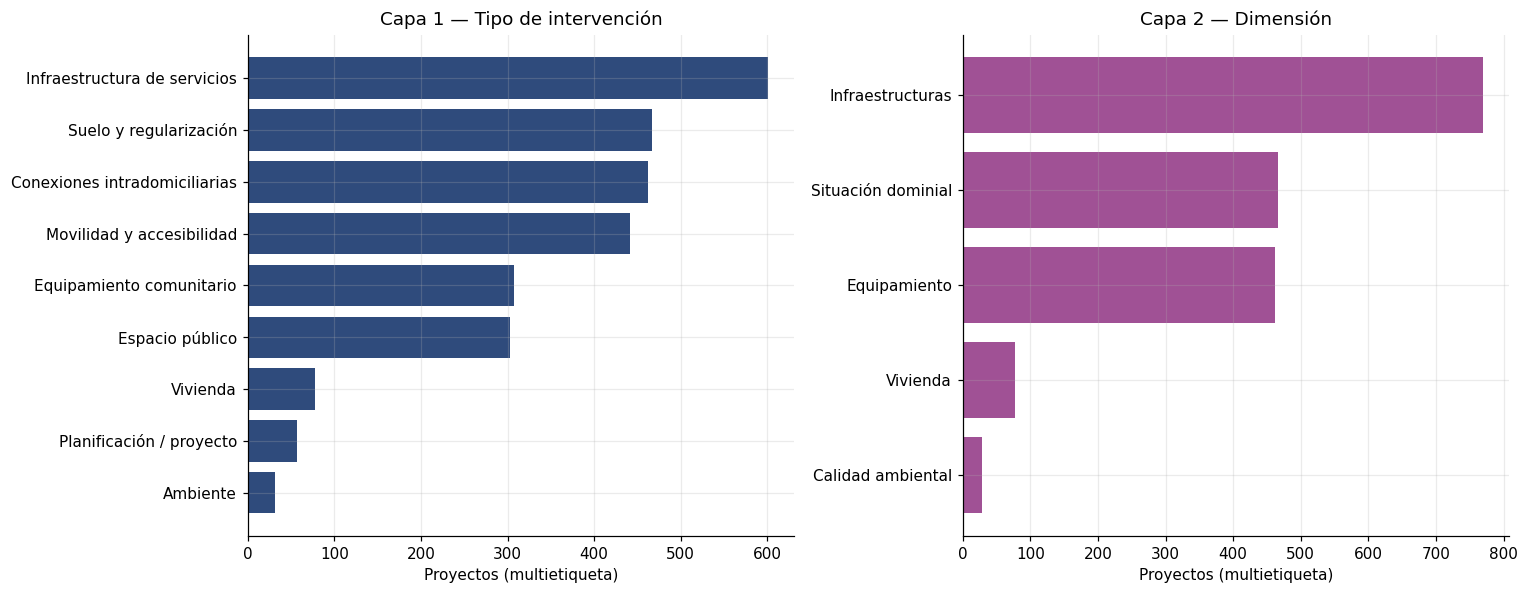

In [1127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
t = tabla_tipos.drop(index="Sin especificar (genéricos)", errors="ignore").sort_values("proyectos")
axes[0].barh(t.index, t["proyectos"], color=PAL[0])
axes[0].set_title("Capa 1 — Tipo de intervención")
axes[0].set_xlabel("Proyectos (multietiqueta)")
d = tabla_dims.sort_values("proyectos")
axes[1].barh(d.index, d["proyectos"], color=PAL[1])
axes[1].set_title("Capa 2 — Dimensión")
axes[1].set_xlabel("Proyectos (multietiqueta)")
plt.tight_layout()
guardar_fig("04_tipos_y_dimensiones")
plt.show()

In [1128]:
# --- Coherencia entre capas: tipo x dimensión principal -------------------
coherencia = pd.crosstab(
    obras["eje_principal"].map(lambda e: EJES_ETIQUETA.get(e, e)),
    obras["dimension_principal"])
guardar_tabla(coherencia, "04_coherencia_tipo_dimension")
coherencia

dimension_principal,Calidad ambiental,Equipamiento,Infraestructuras,Planificación,Sin clasificar,Sin especificar,Situación dominial,Vivienda
eje_principal,,,,,,,,
Ambiente,17,6,1,0,0,0,0,0
Conexiones intradomiciliarias,0,0,9,0,0,0,0,0
Equipamiento comunitario,0,115,0,0,0,0,0,0
Espacio público,0,77,0,0,0,0,0,0
Infraestructura de servicios,0,0,601,0,0,0,0,0
Movilidad y accesibilidad,0,0,159,0,0,0,0,0
Planificación / proyecto,0,0,0,55,0,0,0,0
Suelo y regularización,0,0,0,0,0,0,125,0
Vivienda,0,0,0,0,0,0,1,47


In [1129]:
# --- Capa 3: escala -------------------------------------------------------
escala_tab = pd.DataFrame({
    "proyectos": obras["escala"].value_counts(),
    "%": (obras["escala"].value_counts(normalize=True) * 100).round(1),
})
escala_tab["confirmados por expresión"] = obras[~obras["escala_verificar"]]["escala"].value_counts()
escala_tab["a verificar"] = obras[obras["escala_verificar"]]["escala"].value_counts()
guardar_tabla(escala_tab, "04_escala_nacional")

print(f"Proyectos con escala a verificar: {obras['escala_verificar'].sum()} "
      f"({obras['escala_verificar'].mean()*100:.1f} %)\n")
escala_tab

Proyectos con escala a verificar: 694 (52.8 %)



,proyectos,%,confirmados por expresión,a verificar
escala,,,,
barrial,779,59.20,523.00,256
comunitaria,315,24.00,70.00,245
ambas,120,9.10,28.00,92
sin determinar,101,7.70,NaN,101


In [1130]:
# --- Auditoría: qué quedó sin clasificar ---------------------------------
sin_clas = obras[(obras["eje_principal"] == "sin_clasificar") & (~obras["sin_especificar"])]
print(f"Proyectos sin clasificar por tipo (excluidos los genéricos): {len(sin_clas)}\n")
for nombre, n in sin_clas["nombre_proyecto"].dropna().value_counts().head(25).items():
    print(f"  [{n:3d}] {nombre[:110]}")

print("\n--- Genéricos detectados (muestra) ---")
for nombre, n in obras[obras["sin_especificar"]]["nombre_proyecto"].value_counts().head(10).items():
    print(f"  [{n:3d}] {nombre[:110]}")

Proyectos sin clasificar por tipo (excluidos los genéricos): 23

  [  1] Conexiones e infraestructura
  [  1] POT B° Veintiocho de octubre - Gauchito Gil (ID 5290 - 1101) Infraestructura
  [  1] POT B° Veintiocho de octubre - Gauchito Gil 
  [  1] “Obras de Infraestructura”
  [  1] Infraestructura y obras complementarias
  [  1] Obras de Infraestructura vial y Servicios B° Villa América
  [  1] INTERVENCIÓN INTEGRAL BARRIO EVITA
  [  1] INFRAESTRUCTURA Y OBRAS COMPLEMENTARIAS 
BARRIO MATADERO
  [  1] Proyecto de integración y activación barrial
  [  1] Plan Integral en  Barrio Las Praderas
  [  1] Obras de infraestructura y Mejoramiento de Barrio Carbometal - Localidad Malargue, Municipio de Malargüe.
  [  1] OBRAS DE CONSOLIDACIÓN SOCIO-URBANA, Bº TIERRAS NUEVAS PARA NEUQUÉN
  [  1] Obras de Infraestructura básica en el Barrio Zunchal
  [  1] Obras de Infraestructura Barrio Cantera 25,
  [  1] Urbanización Barrio Pedro Rolón, Nuevo Parque Quirno y Parque Quirno II
  [  1] Obras de Inf

In [1131]:
# --- Contraste de la clasificación entre las dos fuentes ------------------
comparacion_fuentes = pd.DataFrame({
    "datos.gob.ar (%)": [(obras[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
    "Monitor (%)":      [(monitor[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
}, index=[EJES_ETIQUETA[e] for e in EJES])
comparacion_fuentes.loc["Sin especificar"] = [
    round(obras["sin_especificar"].mean() * 100, 1),
    round(monitor["sin_especificar"].mean() * 100, 1)]
guardar_tabla(comparacion_fuentes, "04_comparacion_ejes_fuentes")

print("El Monitor describe la obra enumerando componentes, de modo que su tasa de")
print("'sin especificar' es mucho menor: sirve para imputar los genéricos de datos.gob.ar.\n")
comparacion_fuentes.sort_values("datos.gob.ar (%)", ascending=False)

El Monitor describe la obra enumerando componentes, de modo que su tasa de
'sin especificar' es mucho menor: sirve para imputar los genéricos de datos.gob.ar.



,datos.gob.ar (%),Monitor (%)
Infraestructura de servicios,45.70,63.20
Suelo y regularización,35.50,11.60
Conexiones intradomiciliarias,35.10,0.20
Movilidad y accesibilidad,33.50,48.30
Equipamiento comunitario,23.30,14.20
Espacio público,23.00,0.50
Sin especificar,6.00,0.00
Vivienda,5.90,9.70
Planificación / proyecto,4.30,0.00
Ambiente,2.40,1.70


In [1132]:
# --- Recuperación de genéricos vía Monitor -------------------------------
# Para los proyectos genéricos de datos.gob.ar, se busca si el Monitor describe
# alguna obra en el mismo barrio y se toma su clasificación como imputación.
gen_barrios = set(obras_barrio.loc[obras_barrio["proyecto_id"].isin(
    obras.loc[obras["sin_especificar"], "proyecto_id"]), "id_renabap"])
mon_desc = monitor_barrio[(~monitor_barrio["sin_especificar"]) &
                          (monitor_barrio["id_renabap"].isin(gen_barrios))]

print(f"Barrios con proyecto genérico en datos.gob.ar : {len(gen_barrios)}")
print(f"De ellos, con obra descrita en el Monitor     : {mon_desc['id_renabap'].nunique()} "
      f"({mon_desc['id_renabap'].nunique()/max(len(gen_barrios),1)*100:.1f} %)")
print("\nComposición por dimensión de esas obras del Monitor:")
imput = pd.DataFrame({
    "obras": [mon_desc[f"dim_{d}"].sum() for d in DIMENSIONES],
    "%": [(mon_desc[f"dim_{d}"].mean() * 100).round(1) if len(mon_desc) else 0
          for d in DIMENSIONES],
}, index=DIMENSIONES)
guardar_tabla(imput, "04_imputacion_genericos_monitor")
imput

Barrios con proyecto genérico en datos.gob.ar : 99
De ellos, con obra descrita en el Monitor     : 99 (100.0 %)

Composición por dimensión de esas obras del Monitor:


,obras,%
Infraestructuras,143,84.60
Equipamiento,21,12.40
Calidad ambiental,3,1.80
Situación dominial,7,4.10
Vivienda,25,14.80


La imputación anterior **no se aplica automáticamente** a la tabla de proyectos: se ofrece como evidencia auxiliar. Si decidís usarla, corresponde declararla como criterio de imputación en la nota metodológica y reportar las dos versiones (con y sin imputación).

---
## 5. Análisis nacional — obras

### 5.1 Líneas programáticas y fuentes de financiamiento

In [1133]:
tabla_lp = pd.crosstab(obras["linea_programatica"], obras["financiamiento"], margins=True, margins_name="Total")
guardar_tabla(tabla_lp, "05_linea_x_financiamiento")
tabla_lp

financiamiento,BID,FF,FISU,Total
linea_programatica,,,,
INTEGRAR SALUD,20,0,0,20
LOTES,0,0,106,106
LOTES (Adq.),0,0,15,15
MV,21,0,0,21
PEG,0,0,59,59
POT,9,26,1032,1067
PrePEG,0,20,0,20
VIVIENDA,0,3,4,7
Total,50,49,1216,1315


In [1134]:
montos = (obras.groupby(["financiamiento", "linea_programatica"])["monto_total"]
                .agg(proyectos="count", monto_total="sum", monto_mediano="median")
                .reset_index()
                .sort_values("monto_total", ascending=False))
montos["%_monto"] = (montos["monto_total"] / montos["monto_total"].sum() * 100).round(1)
guardar_tabla(montos.set_index(["financiamiento", "linea_programatica"]), "05_montos_por_linea")
montos

,financiamiento,linea_programatica,proyectos,monto_total,monto_mediano,%_monto
9,FISU,POT,1032,"277,970,150,288.23","133,290,291.80",48.80
6,FISU,LOTES,106,"172,148,222,353.90","1,358,694,157.95",30.20
8,FISU,PEG,59,"102,849,806,716.62","1,194,199,116.72",18.00
7,FISU,LOTES (Adq.),15,"6,457,798,847.75","210,439,608.55",1.10
2,BID,POT,9,"5,963,006,105.32","537,078,730.51",1.00
10,FISU,VIVIENDA,4,"1,783,934,210.92","394,147,310.03",0.30
1,BID,MV,21,"788,493,479.96","41,984,012.55",0.10
5,FF,VIVIENDA,3,"744,081,353.94","272,522,404.00",0.10
3,FF,POT,26,"635,544,822.49","19,926,423.16",0.10
0,BID,INTEGRAR SALUD,20,"609,870,000.00","35,191,500.00",0.10


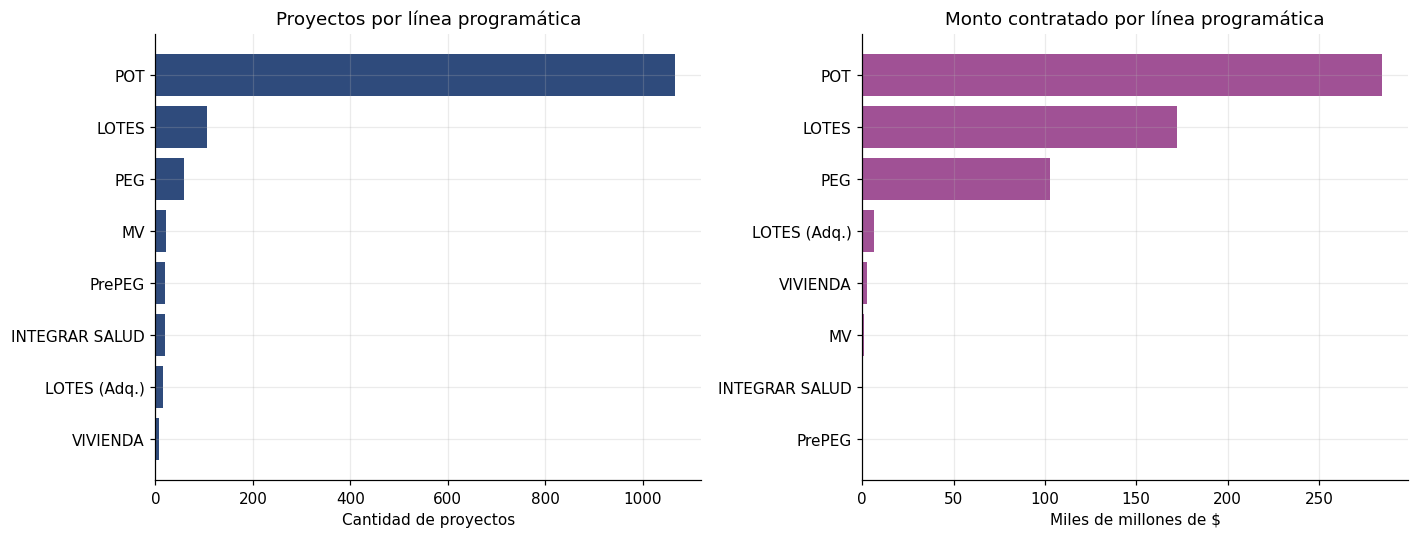

In [1135]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

c1 = obras["linea_programatica"].value_counts()
axes[0].barh(c1.index[::-1], c1.values[::-1], color=PAL[0])
axes[0].set_title("Proyectos por línea programática")
axes[0].set_xlabel("Cantidad de proyectos")

c2 = obras.groupby("linea_programatica")["monto_total"].sum().sort_values()
axes[1].barh(c2.index, c2.values / 1e9, color=PAL[1])
axes[1].set_title("Monto contratado por línea programática")
axes[1].set_xlabel("Miles de millones de $")

plt.tight_layout()
guardar_fig("05_lineas_programaticas")
plt.show()

### 5.2 Estado de avance

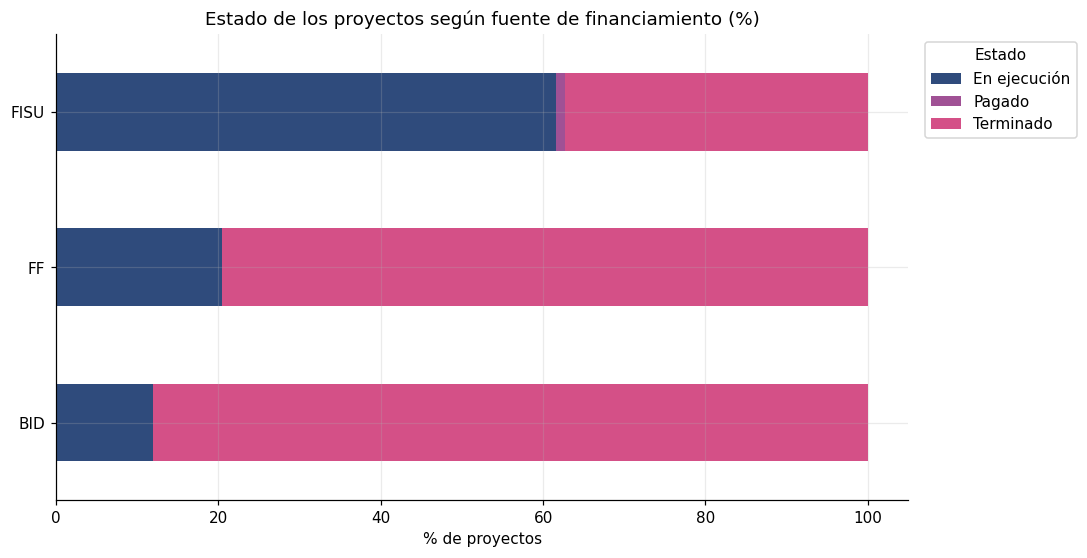

estado,En ejecución,Pagado,Terminado
financiamiento,,,
BID,12.00,0.00,88.00
FF,20.40,0.00,79.60
FISU,61.60,1.10,37.30


In [1136]:
estado_tab = pd.crosstab(obras["financiamiento"], obras["estado"], normalize="index").mul(100).round(1)
guardar_tabla(estado_tab, "05_estado_por_financiamiento")

ax = estado_tab.plot(kind="barh", stacked=True, color=PAL[:estado_tab.shape[1]])
ax.set_title("Estado de los proyectos según fuente de financiamiento (%)")
ax.set_xlabel("% de proyectos"); ax.set_ylabel("")
ax.legend(title="Estado", bbox_to_anchor=(1.01, 1), loc="upper left")
guardar_fig("05_estado_financiamiento")
plt.show()
estado_tab

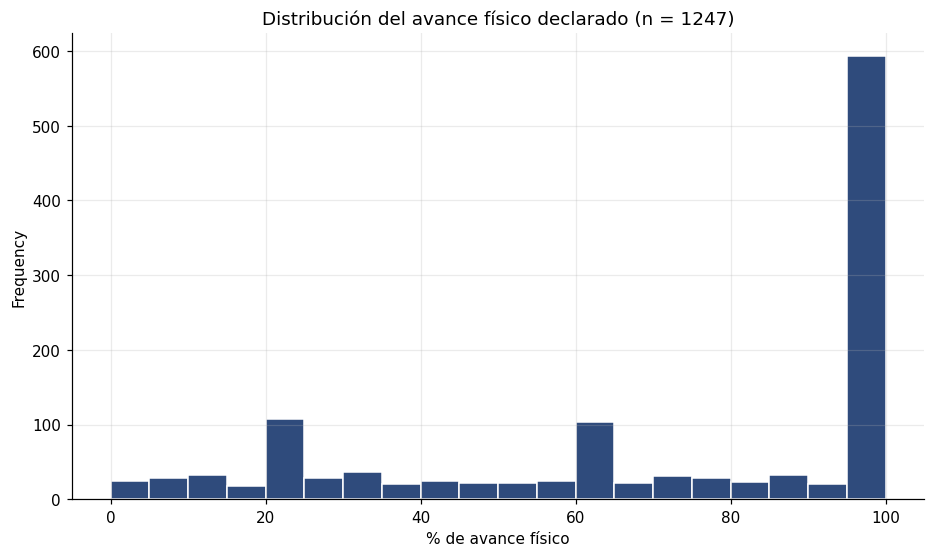

                  count   mean   std   min    25%    50%    75%    max
financiamiento                                                        
BID               30.00  92.40 18.70 29.40 100.00 100.00 100.00 100.00
FF                29.00 100.00  0.10 99.60 100.00 100.00 100.00 100.00
FISU           1,188.00  70.10 33.40  0.00  39.50  84.70 100.00 100.00

Proyectos sin avance informado: 68 (5.2 %)


In [1137]:
# Avance físico declarado: distribución
datos_av = obras["avance_fisico"].dropna()
ax = datos_av.plot(kind="hist", bins=20, color=PAL[0], edgecolor="white")
ax.set_title(f"Distribución del avance físico declarado (n = {len(datos_av)})")
ax.set_xlabel("% de avance físico")
guardar_fig("05_avance_fisico")
plt.show()

print(obras.groupby("financiamiento")["avance_fisico"].describe().round(1))
print(f"\nProyectos sin avance informado: {obras['avance_fisico'].isna().sum()} "
      f"({obras['avance_fisico'].isna().mean()*100:.1f} %)")

### 5.3 Unidad ejecutora — quién ejecuta la política en el territorio

In [1138]:
ue = pd.crosstab(obras["tipo_ue"], obras["financiamiento"])
ue["Total"] = ue.sum(axis=1)
ue_monto = obras.groupby("tipo_ue")["monto_total"].sum()
ue["Monto total"] = ue_monto
ue["Monto promedio"] = obras.groupby("tipo_ue")["monto_total"].mean()
guardar_tabla(ue, "05_unidad_ejecutora")
ue.sort_values("Total", ascending=False)

financiamiento,BID,FF,FISU,Total,Monto total,Monto promedio
tipo_ue,,,,,,
OSC,41,25,772,838,"311,017,475,249.50","371,142,571.90"
Municipio,3,21,314,338,"178,915,914,980.80","529,337,026.57"
Provincia,6,3,76,85,"65,306,478,080.15","768,311,506.83"
Coop. de servicios,0,0,39,39,"8,482,182,009.25","217,491,846.39"
SIN UE,0,0,15,15,"6,457,798,847.75","430,519,923.18"


### 5.4 Distribución federal

In [1139]:
prov = (obras.groupby("provincia")
              .agg(proyectos=("proyecto_id", "count"),
                   monto=("monto_total", "sum"))
              .sort_values("proyectos", ascending=False))
prov["%_proyectos"] = (prov["proyectos"] / prov["proyectos"].sum() * 100).round(1)
prov["%_monto"] = (prov["monto"] / prov["monto"].sum() * 100).round(1)

# Barrios alcanzados por provincia (usa la tabla proyecto–barrio)
prov["barrios_alcanzados"] = obras_barrio.groupby("provincia")["id_renabap"].nunique()
guardar_tabla(prov, "05_distribucion_provincial")
prov.head(25)

,proyectos,monto,%_proyectos,%_monto,barrios_alcanzados
provincia,,,,,
Buenos Aires,665,"261,653,312,452.41",50.60,45.90,513
Santa Fe,79,"33,986,659,895.24",6.00,6.00,85
Tucumán,65,"29,828,793,143.24",4.90,5.20,57
Río Negro,51,"22,957,021,125.40",3.90,4.00,65
Córdoba,50,"24,177,609,891.62",3.80,4.20,34
Misiones,44,"28,627,343,224.19",3.30,5.00,46
Chaco,43,"18,658,091,575.04",3.30,3.30,38
Mendoza,41,"20,024,496,035.02",3.10,3.50,39
Entre Ríos,37,"21,968,241,671.47",2.80,3.90,32


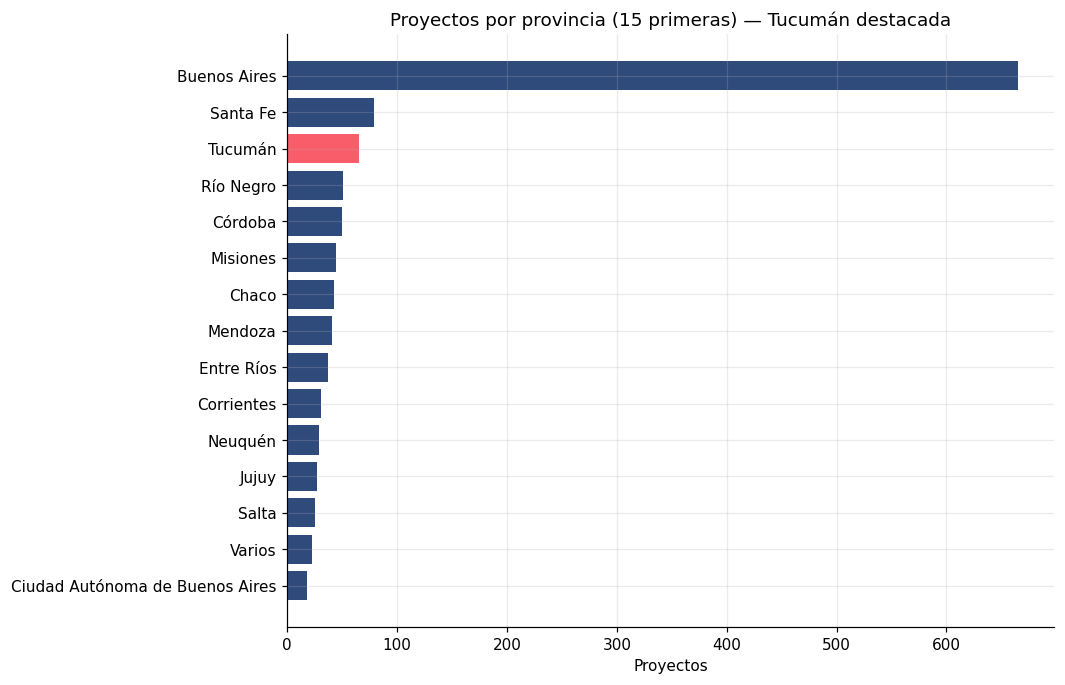

In [1140]:
top = prov.head(15).sort_values("proyectos")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top["proyectos"], color=[PAL[3] if p == "Tucumán" else PAL[0] for p in top.index])
ax.set_title("Proyectos por provincia (15 primeras) — Tucumán destacada")
ax.set_xlabel("Proyectos")
guardar_fig("05_provincias")
plt.show()

### 5.5 Cobertura territorial: cuántos barrios populares fueron efectivamente alcanzados

In [1141]:
cob = pd.DataFrame({
    "fuente": ["datos.gob.ar", "Monitor de obras", "Mi Pieza (monitor)"],
    "registros": [len(obras), len(monitor), len(mipieza_mon)],
    "barrios_únicos": [obras_barrio["id_renabap"].nunique(),
                       monitor_barrio["id_renabap"].nunique(),
                       mipieza_mon_barrio["id_renabap"].nunique()],
})
guardar_tabla(cob.set_index("fuente"), "05_cobertura_fuentes")
print(cob.to_string(index=False))

s_dg  = set(obras_barrio["id_renabap"])
s_mon = set(monitor_barrio["id_renabap"])
s_mp  = set(mipieza_mon_barrio["id_renabap"])

print(f"\nBarrios en ambas fuentes de obras: {len(s_dg & s_mon)}")
print(f"Sólo en datos.gob.ar: {len(s_dg - s_mon)}")
print(f"Sólo en el Monitor:   {len(s_mon - s_dg)}")
print(f"Barrios con obra Y con Mi Pieza: {len((s_dg | s_mon) & s_mp)}")
print(f"Barrios sólo con Mi Pieza (sin obra de infraestructura): {len(s_mp - (s_dg | s_mon))}")

            fuente  registros  barrios_únicos
      datos.gob.ar       1315            1224
  Monitor de obras       1322            1224
Mi Pieza (monitor)       5051            5051

Barrios en ambas fuentes de obras: 1223
Sólo en datos.gob.ar: 1
Sólo en el Monitor:   1
Barrios con obra Y con Mi Pieza: 1188
Barrios sólo con Mi Pieza (sin obra de infraestructura): 3863


La última cifra es sustantiva para el argumento: mide cuántos barrios recibieron **únicamente** la transferencia individual de Mi Pieza, sin ninguna obra de integración urbana asociada.

---
## 6. Análisis nacional — Mi Pieza

In [1142]:
resumen_mp = pd.DataFrame({
    "adjudicaciones": [len(mipieza)],
    "monto_total": [mipieza["monto"].sum()],
    "monto_promedio": [mipieza["monto"].mean()],
    "barrios_alcanzados": [mipieza["id_barrio"].nunique()],
    "provincias": [mipieza["provincia"].nunique()],
})
print(resumen_mp.T.to_string(header=False))

print("\nPor estado:")
print(mipieza["estado"].value_counts(dropna=False))

adjudicaciones             489,429.00
monto_total        219,036,390,000.00
monto_promedio             447,534.56
barrios_alcanzados           5,406.00
provincias                      24.00

Por estado:
estado
Activa          235783
inscripta       233833
seleccionada     15109
Seleccionada      4704
Name: count, dtype: Int64


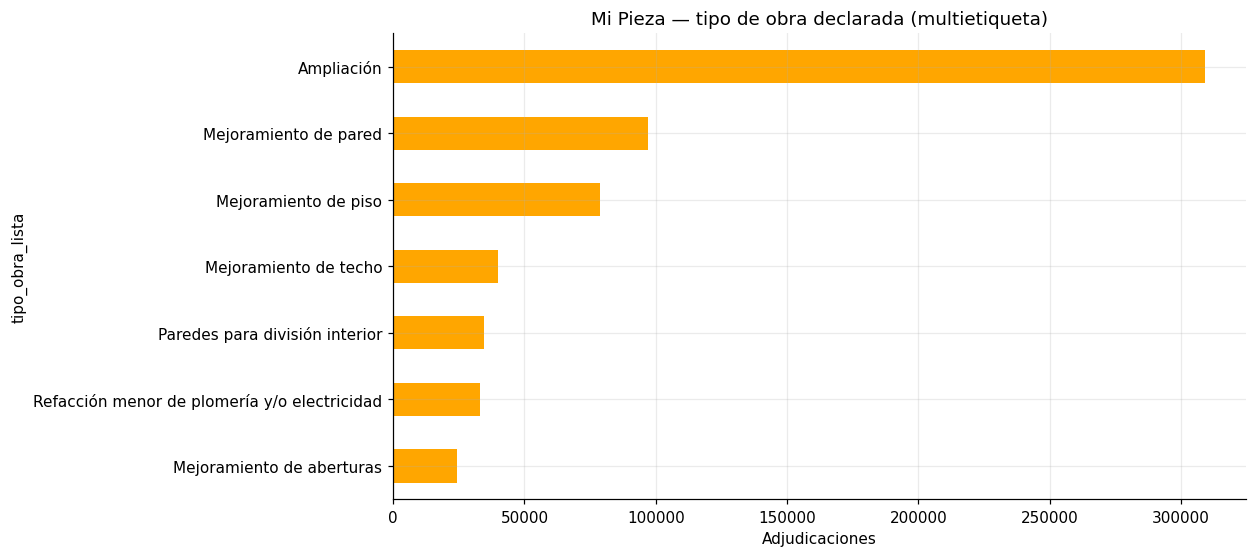

,adjudicaciones,monto,%
tipo_obra_lista,,,
Ampliación,309104,142119240000,63.20
Mejoramiento de pared,97045,42172890000,19.80
Mejoramiento de piso,78723,35037070000,16.10
Mejoramiento de techo,39754,17706840000,8.10
Paredes para división interior,34654,14664800000,7.10
Refacción menor de plomería y/o electricidad,33247,14487410000,6.80
Mejoramiento de aberturas,24301,10540660000,5.00


In [1143]:
tipos_mp_tab = (mipieza.explode("tipo_obra_lista")
                       .groupby("tipo_obra_lista")
                       .agg(adjudicaciones=("id", "count"), monto=("monto", "sum"))
                       .sort_values("adjudicaciones", ascending=False))
tipos_mp_tab["%"] = (tipos_mp_tab["adjudicaciones"] / len(mipieza) * 100).round(1)
guardar_tabla(tipos_mp_tab, "06_mipieza_tipos_obra")

ax = tipos_mp_tab["adjudicaciones"].sort_values().plot(kind="barh", color=PAL[5])
ax.set_title("Mi Pieza — tipo de obra declarada (multietiqueta)")
ax.set_xlabel("Adjudicaciones")
guardar_fig("06_mipieza_tipos")
plt.show()
tipos_mp_tab

In [1144]:
# Condiciones materiales de la vivienda al momento de la solicitud
for col in ["piso_vivienda", "pared_vivienda", "techo_vivienda"]:
    print(f"\n--- {col} ---")
    print((mipieza[col].value_counts(normalize=True) * 100).round(1).head(8))


--- piso_vivienda ---
piso_vivienda
Cemento alisado                     58.70
Mosaico baldosa cerámica o mármol   17.20
Ladrillo suelto o tierra            11.90
Cemento o ladrillo fijo              8.20
Madera                               3.60
Alfombra o goma                      0.40
Name: proportion, dtype: float64

--- pared_vivienda ---
pared_vivienda
Ladrillo                            74.80
Madera                              15.10
Piedra bloque u hormigón             5.60
Chapa metal o fibrocemento           2.70
Cartón paja o material de desecho    1.10
Adobe                                0.70
Name: proportion, dtype: float64

--- techo_vivienda ---
techo_vivienda
Chapa                                                     77.00
Losa                                                      16.40
Cubierta provisoria (paja, caña, plástico, cartón, etc)    5.90
Teja                                                       0.60
Cubierta provisoria                                        

In [1145]:
prov_mp = (mipieza.groupby("provincia")
                  .agg(adjudicaciones=("id", "count"),
                       monto=("monto", "sum"),
                       barrios=("id_barrio", "nunique"))
                  .sort_values("adjudicaciones", ascending=False))
prov_mp["%_adjudicaciones"] = (prov_mp["adjudicaciones"] / len(mipieza) * 100).round(1)
guardar_tabla(prov_mp, "06_mipieza_provincias")
prov_mp.head(25)

,adjudicaciones,monto,barrios,%_adjudicaciones
provincia,,,,
Buenos Aires,251032,111651770000,1935,51.30
Santa Fe,43274,19886570000,375,8.80
Misiones,25014,11486950000,357,5.10
Chaco,24002,11085780000,352,4.90
Córdoba,17166,7456740000,274,3.50
Corrientes,16353,7057300000,183,3.30
Salta,14148,6086890000,202,2.90
Tucumán,13845,6412540000,257,2.80
Ciudad Autónoma de Buenos Aires,12916,5797860000,61,2.60


In [1146]:
# Contraste entre las dos fuentes de Mi Pieza a nivel provincial
comp_mp = pd.DataFrame({
    "microdato (adjudicaciones)": mipieza.groupby(mipieza["provincia"].map(norm_texto)).size(),
    "monitor (obras_total)": mipieza_mon.groupby("provincia_norm")["obras_total"].sum(),
    "monitor (inversión)": mipieza_mon.groupby("provincia_norm")["inversion_total"].sum(),
    "microdato (monto)": mipieza.groupby(mipieza["provincia"].map(norm_texto))["monto"].sum(),
})
comp_mp["ratio_registros"] = (comp_mp["monitor (obras_total)"] / comp_mp["microdato (adjudicaciones)"]).round(2)
guardar_tabla(comp_mp, "06_mipieza_comparacion_fuentes")
comp_mp.sort_values("microdato (adjudicaciones)", ascending=False).head(25)

,microdato (adjudicaciones),monitor (obras_total),monitor (inversión),microdato (monto),ratio_registros
buenos aires,251032,"122,187.00","41,045,870,000.00",111651770000,0.49
santa fe,43274,"19,885.00","7,001,070,000.00",19886570000,0.46
misiones,25014,"11,499.00","4,074,990,000.00",11486950000,0.46
chaco,24002,"11,083.00","4,029,480,000.00",11085780000,0.46
cordoba,17166,"8,608.00","2,916,180,000.00",7456740000,0.50
corrientes,16353,"8,395.00","2,791,540,000.00",7057300000,0.51
salta,14148,"7,723.00","2,726,910,000.00",6086890000,0.55
tucuman,13845,"6,399.00","2,319,880,000.00",6412540000,0.46
ciudad autonoma de buenos aires,12916,"6,009.00","2,084,040,000.00",5797860000,0.47
entre rios,12086,"5,884.00","2,004,930,000.00",5390350000,0.49


Las diferencias entre ambas fuentes no son ruido: el microdato registra **adjudicaciones** (incluidas las no ejecutadas o rechazadas) mientras que el Monitor contabiliza **obras** en sus tres estados más los rechazos por separado. Conviene explicitar en la tesis cuál de los dos universos se está reportando.

---
## 7. Recorte metropolitano — AMT

El recorte se hace por `id_renabap` contra los subconjuntos ya validados espacialmente en QGIS, no por nombre de municipio. Esto evita los problemas de las bases nacionales: municipios escritos de forma inconsistente, localidades del AMT registradas bajo comunas rurales, y proyectos que declaran municipio pero no barrio.

Se calcula además, como control, el recorte por nombre de municipio, para dimensionar cuántos registros se pierden al depender del identificador.

In [1147]:
# --- 7.1 Recorte por identificador (criterio principal) -------------------
obras_amt_barrio = obras_barrio[obras_barrio["id_renabap"].isin(IDS_AMT)].copy()
proyectos_amt_ids = set(obras_amt_barrio["proyecto_id"])
obras_amt = obras[obras["proyecto_id"].isin(proyectos_amt_ids)].copy()

monitor_amt_barrio = monitor_barrio[monitor_barrio["id_renabap"].isin(IDS_AMT)].copy()
monitor_amt = monitor[monitor["obra_id"].isin(set(monitor_amt_barrio["obra_id"]))].copy()

mp_amt = mipieza[mipieza["id_barrio"].isin(IDS_AMT)].copy()
# Universo efectivo: sólo lo adjudicado. Las inscriptas se reportan aparte.
mp_amt_adj = mp_amt[mp_amt["adjudicada"]].copy()
mp_mon_amt = mipieza_mon_barrio[mipieza_mon_barrio["id_renabap"].isin(IDS_AMT)].copy()

print(f"Universo AMT: {len(IDS_AMT)} barrios")
print(f"  Proyectos (datos.gob.ar) : {len(obras_amt)}")
print(f"  Obras (Monitor)          : {len(monitor_amt)}")
print(f"  Mi Pieza — registros     : {len(mp_amt)}")
print(f"     de los cuales adjudicados: {len(mp_amt_adj)} "
      f"({len(mp_amt_adj)/max(len(mp_amt),1)*100:.1f} %)")
print(f"     inscriptas sin adjudicar : {len(mp_amt) - len(mp_amt_adj)}")
print(f"  Barrios AMT con obra     : {obras_amt_barrio['id_renabap'].nunique()} "
      f"({obras_amt_barrio['id_renabap'].nunique()/len(IDS_AMT)*100:.1f} % del universo)")
print(f"  Barrios AMT con Mi Pieza adjudicada: {mp_amt_adj['id_barrio'].nunique()} "
      f"({mp_amt_adj['id_barrio'].nunique()/len(IDS_AMT)*100:.1f} %)")

Universo AMT: 214 barrios
  Proyectos (datos.gob.ar) : 50
  Obras (Monitor)          : 51
  Mi Pieza — registros     : 12012
     de los cuales adjudicados: 5599 (46.6 %)
     inscriptas sin adjudicar : 6413
  Barrios AMT con obra     : 41 (19.2 % del universo)
  Barrios AMT con Mi Pieza adjudicada: 144 (67.3 %)


In [1148]:
# --- 7.2 Control: recorte por nombre de municipio -------------------------
# Lista provisional de municipios y comunas del AMT — AJUSTAR según la
# delimitación usada en QGIS (limite_amt.gpkg).
MUNICIPIOS_AMT = [
    "san miguel de tucuman", "yerba buena", "tafi viejo", "las talitas",
    "banda del rio sali", "alderetes", "lules", "san isidro de lules",
    "el manantial", "san pablo y villa nougues", "cevil redondo",
    "los pocitos", "san felipe y santa barbara", "la esperanza",
    "colombres", "delfin gallo", "los nogales", "san andres",
]


obras_amt_muni = obras[obras["municipio_amt"].isin(
    [unificar_municipio(m) for m in MUNICIPIOS_AMT])]
solo_muni = set(obras_amt_muni["proyecto_id"]) - proyectos_amt_ids
solo_id   = proyectos_amt_ids - set(obras_amt_muni["proyecto_id"])

print(f"Proyectos captados por identificador : {len(proyectos_amt_ids)}")
print(f"Proyectos captados por municipio     : {len(obras_amt_muni)}")
print(f"Sólo por municipio (id ausente/compuesto no AMT): {len(solo_muni)}")
print(f"Sólo por identificador (municipio mal escrito o ausente): {len(solo_id)}")

if solo_muni:
    print("\nRevisar estos proyectos — tienen municipio del AMT pero no entraron por id:\n")
    print(obras.loc[obras["proyecto_id"].isin(solo_muni),
                    ["municipio", "barrio", "id_renabap_raw", "linea_programatica",
                     "financiamiento", "nombre_proyecto"]].head(20).to_string(index=False))

Proyectos captados por identificador : 50
Proyectos captados por municipio     : 50
Sólo por municipio (id ausente/compuesto no AMT): 2
Sólo por identificador (municipio mal escrito o ausente): 2

Revisar estos proyectos — tienen municipio del AMT pero no entraron por id:

          municipio barrio id_renabap_raw linea_programatica financiamiento                                                                            nombre_proyecto
              Lules    NaN            NaN              LOTES           FISU Adquisición de tierra privada y desarrollo de infraestructura para 261 lotes con servicios
San Isidro De Lules Ahuala           4045                POT           FISU                                                          Obras de Integración Socio Urbana


La celda anterior es una decisión metodológica, no un chequeo técnico: si aparecen muchos proyectos "sólo por municipio", el recorte por identificador está subregistrando la inversión en el AMT y hay que documentarlo o ampliar el criterio.

### 7.3 Caracterización de las intervenciones en el AMT

In [1149]:
resumen_amt = pd.DataFrame({
    "indicador": [
        "Barrios populares en el AMT (universo)",
        "Barrios con al menos un proyecto de obra",
        "Barrios con al menos una adjudicación Mi Pieza (Activa o Seleccionada)",
        "Barrios sin ninguna intervención registrada",
        "Proyectos de obra (datos.gob.ar)",
        "Monto contratado total ($)",
        "Adjudicaciones Mi Pieza",
        "Monto Mi Pieza ($)",
    ],
    "valor": [
        len(IDS_AMT),
        obras_amt_barrio["id_renabap"].nunique(),
        mp_amt_adj["id_barrio"].nunique(),
        len(IDS_AMT - set(obras_amt_barrio["id_renabap"]) - set(mp_amt_adj["id_barrio"])),
        len(obras_amt),
        obras_amt["monto_total"].sum(),
        len(mp_amt_adj),
        mp_amt_adj["monto"].sum(),
    ],
})
guardar_tabla(resumen_amt.set_index("indicador"), "07_resumen_amt")
resumen_amt

,indicador,valor
0,Barrios populares en el AMT (universo),214.00
1,Barrios con al menos un proyecto de obra,41.00
2,Barrios con al menos una adjudicación Mi Pieza...,144.00
3,Barrios sin ninguna intervención registrada,70.00
4,Proyectos de obra (datos.gob.ar),50.00
5,Monto contratado total ($),"20,177,934,487.47"
6,Adjudicaciones Mi Pieza,"5,599.00"
7,Monto Mi Pieza ($),"1,845,030,000.00"


In [1150]:
tabla_amt_lp = pd.crosstab(obras_amt["linea_programatica"], obras_amt["financiamiento"],
                           margins=True, margins_name="Total")
guardar_tabla(tabla_amt_lp, "07_amt_linea_x_financiamiento")
tabla_amt_lp

financiamiento,BID,FF,FISU,Total
linea_programatica,,,,
INTEGRAR SALUD,2,0,0,2
POT,3,1,43,47
PrePEG,0,1,0,1
Total,5,2,43,50


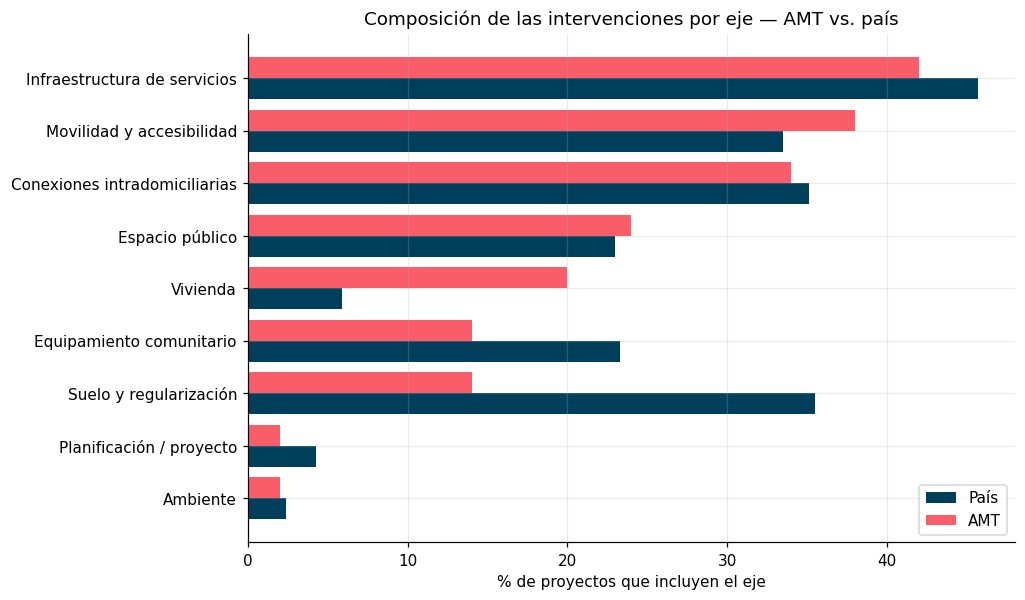

,AMT — proyectos,AMT — %,País — %,Brecha (AMT − país)
Infraestructura de servicios,21,42.00,45.70,-3.70
Conexiones intradomiciliarias,17,34.00,35.10,-1.10
Movilidad y accesibilidad,19,38.00,33.50,4.50
Ambiente,1,2.00,2.40,-0.40
Espacio público,12,24.00,23.00,1.00
Equipamiento comunitario,7,14.00,23.30,-9.30
Vivienda,10,20.00,5.90,14.10
Suelo y regularización,7,14.00,35.50,-21.50
Planificación / proyecto,1,2.00,4.30,-2.30


In [1151]:
ejes_amt = pd.DataFrame({
    "AMT — proyectos": [obras_amt[f"eje_{e}"].sum() for e in EJES],
    "AMT — %":         [(obras_amt[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
    "País — %":        [(obras[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
}, index=[EJES_ETIQUETA[e] for e in EJES])
ejes_amt["Brecha (AMT − país)"] = (ejes_amt["AMT — %"] - ejes_amt["País — %"]).round(1)
guardar_tabla(ejes_amt, "07_amt_ejes")

comp = ejes_amt.sort_values("AMT — %")
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(comp))
ax.barh(y - 0.2, comp["País — %"], height=0.4, color=PAL[7], label="País")
ax.barh(y + 0.2, comp["AMT — %"], height=0.4, color=PAL[3], label="AMT")
ax.set_yticks(y); ax.set_yticklabels(comp.index)
ax.set_xlabel("% de proyectos que incluyen el eje")
ax.set_title("Composición de las intervenciones por eje — AMT vs. país")
ax.legend()
guardar_fig("07_amt_vs_pais_ejes")
plt.show()
ejes_amt

In [1152]:
# --- AMT: dimensiones y escala -------------------------------------------
dim_amt = pd.DataFrame({
    "AMT — proyectos": [obras_amt[f"dim_{d}"].sum() for d in DIMENSIONES],
    "AMT — %":         [(obras_amt[f"dim_{d}"].mean() * 100).round(1) for d in DIMENSIONES],
    "País — %":        [(obras[f"dim_{d}"].mean() * 100).round(1) for d in DIMENSIONES],
    "AMT — monto":     [obras_amt.loc[obras_amt[f"dim_{d}"], "monto_total"].sum()
                        for d in DIMENSIONES],
}, index=DIMENSIONES)
guardar_tabla(dim_amt, "07_amt_dimensiones")

sub_amt = pd.DataFrame({
    "dimensión": [SUBDIMENSIONES[x]["dimension"] for x in SUBDIMENSIONES],
    "proyectos": [obras_amt[f"sub_{x}"].sum() for x in SUBDIMENSIONES],
    "%":         [(obras_amt[f"sub_{x}"].mean() * 100).round(1) for x in SUBDIMENSIONES],
}, index=[SUBDIMENSIONES[x]["etiqueta"] for x in SUBDIMENSIONES])
guardar_tabla(sub_amt, "07_amt_subdimensiones")

escala_amt = pd.DataFrame({
    "proyectos": obras_amt["escala"].value_counts(),
    "%": (obras_amt["escala"].value_counts(normalize=True) * 100).round(1),
})
guardar_tabla(escala_amt, "07_amt_escala")

print("Dimensiones — AMT:")
display(dim_amt)
print(f"\nEscala de las intervenciones en el AMT "
      f"({obras_amt['escala_verificar'].sum()} de {len(obras_amt)} a verificar):")
display(escala_amt)
print("\nSubdimensiones — AMT:")
sub_amt.sort_values("proyectos", ascending=False)

Dimensiones — AMT:


,AMT — proyectos,AMT — %,País — %,AMT — monto
Infraestructuras,29,58.00,58.60,"6,091,331,026.80"
Equipamiento,16,32.00,35.10,"2,528,391,254.76"
Calidad ambiental,1,2.00,2.10,"1,097,517,556.25"
Situación dominial,7,14.00,35.50,"1,690,616,184.26"
Vivienda,10,20.00,5.90,"3,618,985,805.97"



Escala de las intervenciones en el AMT (17 de 50 a verificar):


,proyectos,%
escala,,
barrial,34,68.00
comunitaria,8,16.00
ambas,6,12.00
sin determinar,2,4.00



Subdimensiones — AMT:


,dimensión,proyectos,%
Servicios básicos y energía,Infraestructuras,21,42.00
Movilidad y conectividad,Infraestructuras,19,38.00
"Espacio público, deporte y cultura",Equipamiento,12,24.00
Mejoramiento y provisión de vivienda,Vivienda,10,20.00
Regularización y seguridad en la tenencia,Situación dominial,7,14.00
Administración y bienestar,Equipamiento,4,8.00
Salud y educación,Equipamiento,3,6.00
Condiciones ambientales,Calidad ambiental,1,2.00
Planificación y proyecto,Planificación,1,2.00
Servicios y consumo,Equipamiento,0,0.00


La distribución por escala es el indicador más directo de la hipótesis: si el peso de lo *barrial* domina y lo *comunitario* se concentra en unos pocos proyectos, la afirmación de que la política circunscribe su alcance al mejoramiento intra-barrial queda respaldada por la propia declaración de las obras. Conviene reportarla junto con el porcentaje pendiente de verificación, para no presentar como dato lo que todavía es inferencia sobre el nombre del proyecto.

In [1153]:
# Distribución interna del AMT por municipio
amt_muni = (obras_amt_barrio
            .drop_duplicates(subset=["proyecto_id", "municipio_amt"])
            .groupby("municipio_amt")
            .agg(proyectos=("proyecto_id", "nunique"),
                 barrios=("id_renabap", "nunique"))
            .sort_values("proyectos", ascending=False))
guardar_tabla(amt_muni, "07_amt_por_municipio")
amt_muni

,proyectos,barrios
municipio_amt,,
san miguel de tucuman,30,18
tafi viejo,8,5
alderetes,3,2
las talitas,3,3
varios,2,2
san felipe y santa barbara,1,1
el manantial,1,1
banda del rio sali,1,1
san pablo y villa nougues,1,1


In [1154]:
# Barrios del AMT ordenados por intervención recibida
det_barrio = (obras_amt_barrio
              .groupby("id_renabap")
              .agg(proyectos=("proyecto_id", "nunique"),
                   barrio=("barrio", "first"),
                   municipio=("municipio", "first"),
                   lineas=("linea_programatica", lambda s: ", ".join(sorted(set(s.dropna())))),
                   financiamientos=("financiamiento", lambda s: ", ".join(sorted(set(s.dropna()))))))

mp_por_barrio = mp_amt_adj.groupby("id_barrio").agg(mipieza_adj=("id", "count"),
                                                    mipieza_monto=("monto", "sum"))
det_barrio = det_barrio.join(mp_por_barrio, how="outer")
det_barrio[["proyectos", "mipieza_adj"]] = det_barrio[["proyectos", "mipieza_adj"]].fillna(0)

# Completar nombre desde el corte 2023 del AMT para los barrios que sólo tienen Mi Pieza
det_barrio["barrio"] = det_barrio["barrio"].fillna(pd.Series(NOMBRES_AMT))

det_barrio = det_barrio.sort_values(["proyectos", "mipieza_adj"], ascending=False)
guardar_tabla(det_barrio, "07_amt_detalle_por_barrio")
det_barrio.head(30)

,proyectos,barrio,municipio,lineas,financiamientos,mipieza_adj,mipieza_monto
2745,5.00,ATE,San Miguel De Tucumán,POT,FISU,141,49150000
4507,4.00,Ampliación Muñecas III,San Miguel De Tucumán,POT,FISU,137,40230000
2762,4.00,Autopista Sur/ Los Vázquez,San Miguel De Tucumán,POT,"BID, FISU",47,15840000
2760,3.00,Los Vazquez y Autopista Sur,San Miguel de Tucumán,POT,BID,119,40650000
4073,2.00,Julio Abraham,Alderetes,POT,FISU,174,74830000
2763,2.00,Barrio Margaritas,San Miguel De Tucumán,POT,FISU,49,17770000
4128,2.00,Barrio Calpini,Tafí Viejo,POT,FISU,38,15360000
4119,2.00,"Divino Niño Jesús, Cortada de Matorel y Amplia...",Tafí Viejo,"POT, PrePEG","FF, FISU",26,7180000
2779,2.00,Ciudadela Norte,San Miguel De Tucumán,POT,FISU,22,12850000
4050,2.00,La Nina,Tafí Viejo,POT,"FF, FISU",20,7180000


In [1155]:
# Barrios del AMT SIN ninguna intervención registrada
sin_interv = IDS_AMT - set(obras_amt_barrio["id_renabap"]) - set(mp_amt_adj["id_barrio"])
tabla_sin = amt["2023"][amt["2023"]["id_renabap"].isin(sin_interv)][
    ["id_renabap", "nombre_barrio", "localidad", "cantidad_familias_aproximada",
     "clasificacion_barrio", "agua_corriente", "efluentes_cloacales", "energia_electrica"]
]
guardar_tabla(tabla_sin.set_index("id_renabap"), "07_amt_barrios_sin_intervencion")
print(f"Barrios del AMT sin intervención registrada: {len(sin_interv)}")
tabla_sin.head(30)

Barrios del AMT sin intervención registrada: 70


,id_renabap,nombre_barrio,localidad,cantidad_familias_aproximada,clasificacion_barrio,agua_corriente,efluentes_cloacales,energia_electrica
2,2747,Villa 9 de Julio II,San Miguel De Tucumán,28,Villa,Conexión irregular a la red de agua,Desagüe sólo a pozo negro/ciego u hoyo,Conexión irregular a la red
37,2785,130 Vivendas,Alderetes,36,Asentamiento,Conexión irregular a la red de agua,Desagüe sólo a pozo negro/ciego u hoyo,Conexión formal a la red con medidor domicilia...
64,4053,Entrada de Los Sánchez,Los Nogales,22,Asentamiento,Conexión irregular a la red de agua,Desagüe sólo a pozo negro/ciego u hoyo,Conexión irregular a la red
69,4058,Holguín,El Manantial,32,Asentamiento,Bomba de agua de pozo comunitaria,Desagüe sólo a pozo negro/ciego u hoyo,Conexión formal a la red con medidor domicilia...
86,4075,Presidente Perón,Banda Del Río Salí,275,Asentamiento,Conexión irregular a la red de agua,Desagüe sólo a pozo negro/ciego u hoyo,Conexión formal a la red con medidor domicilia...
88,4077,Tres de Noviembre,Alderetes,80,Asentamiento,Conexión irregular a la red de agua,Desagüe sólo a pozo negro/ciego u hoyo,Conexión formal a la red con medidor domicilia...
89,4078,Sin Nombre,Alderetes,40,Villa,Conexión irregular a la red de agua,Desagüe sólo a pozo negro/ciego u hoyo,Conexión formal a la red con medidor domicilia...
90,4079,Evangelina Salazar,Alderetes,110,Asentamiento,Conexión irregular a la red de agua,Desagüe sólo a pozo negro/ciego u hoyo,Conexión formal a la red con medidor domicilia...
91,4080,Nahuel Huapi,Alderetes,169,Asentamiento,Conexión irregular a la red de agua,Desagüe sólo a pozo negro/ciego u hoyo,Conexión formal a la red con medidor domicilia...
93,4082,Jerusalén,Alderetes,242,Villa,Conexión irregular a la red de agua,Desagüe sólo a pozo negro/ciego u hoyo,Conexión formal a la red con medidor domicilia...


Esta última tabla es el reverso analítico del bloque: permite preguntar si los barrios **no alcanzados** por la política se diferencian sistemáticamente de los alcanzados en tamaño, tipología o déficit de servicios.

In [1156]:
# --- Contraste: ¿los barrios intervenidos tienen perfil distinto? ---------
base23 = amt["2023"].copy()
base23["intervenido"] = np.where(base23["id_renabap"].isin(set(obras_amt_barrio["id_renabap"])),
                                 "Con obra", "Sin obra")
base23["familias"] = pd.to_numeric(base23["cantidad_familias_aproximada"], errors="coerce")
base23["superficie_m2"] = pd.to_numeric(base23["superficie_m2"], errors="coerce")

perfil = base23.groupby("intervenido").agg(
    barrios=("id_renabap", "count"),
    familias_mediana=("familias", "median"),
    familias_total=("familias", "sum"),
    superficie_mediana=("superficie_m2", "median"),
)
guardar_tabla(perfil, "07_amt_perfil_intervenidos")
print(perfil)

print("\nTipología barrial:")
print(pd.crosstab(base23["clasificacion_barrio"], base23["intervenido"], normalize="columns").mul(100).round(1))

print("\nAcceso al agua corriente:")
print(pd.crosstab(base23["agua_corriente"], base23["intervenido"], normalize="columns").mul(100).round(1))

             barrios  familias_mediana  familias_total  superficie_mediana
intervenido                                                               
Con obra          40            229.00           16193           86,537.00
Sin obra         173             66.00           21941           26,761.00

Tipología barrial:
intervenido                        Con obra  Sin obra
clasificacion_barrio                                 
Asentamiento                          70.00     71.70
Conjunto habitacional unifamiliar      0.00      2.90
Villa                                 30.00     25.40

Acceso al agua corriente:
intervenido                                         Con obra  Sin obra
agua_corriente                                                        
Bomba de agua de pozo comunitaria                      10.00     12.10
Bomba de agua de pozo domiciliaria                      2.50      1.20
Camión cisterna                                         0.00      1.20
Canilla comunitaria dentro d

### 7.4 Mi Pieza en el AMT

In [1157]:
print(f"Registros Mi Pieza en el AMT      : {len(mp_amt)}")
print(f"  adjudicados (Activa+Seleccionada): {len(mp_amt_adj)}")
print(f"Monto adjudicado : $ {mp_amt_adj['monto'].sum():,.0f}")
print(f"Monto promedio   : $ {mp_amt_adj['monto'].mean():,.0f}")
print(f"Barrios alcanzados: {mp_amt_adj['id_barrio'].nunique()} de {len(IDS_AMT)}")
print("\nEstado de los registros:")
print(mp_amt["estado_norm"].value_counts())

print("\nTipo de obra × estado en el AMT:")
_l = mp_amt.explode("tipo_obra_lista").reset_index(drop=True)
_l = _l[_l["tipo_obra_lista"].notna()]
display(pd.crosstab(_l["tipo_obra_lista"], _l["estado_norm"]))

tipos_amt = (mp_amt_adj.explode("tipo_obra_lista")["tipo_obra_lista"].value_counts())
tipos_amt_pct = (tipos_amt / len(mp_amt_adj) * 100).round(1)
comp_tipos = pd.DataFrame({"AMT (%)": tipos_amt_pct,
                           "País (%)": (tipos_mp / len(mipieza) * 100).round(1)})
comp_tipos.index.name = "Tipo de obra (sólo adjudicadas en AMT)"
guardar_tabla(comp_tipos, "07_amt_mipieza_tipos")
comp_tipos

Registros Mi Pieza en el AMT      : 12012
  adjudicados (Activa+Seleccionada): 5599
Monto adjudicado : $ 1,845,030,000
Monto promedio   : $ 329,528
Barrios alcanzados: 144 de 214

Estado de los registros:
estado_norm
Inscripta       5957
Activa          5599
Seleccionada     456
Name: count, dtype: int64

Tipo de obra × estado en el AMT:


estado_norm,Activa,Inscripta,Seleccionada
tipo_obra_lista,,,
Ampliación,3629,4116,306
Mejoramiento de aberturas,192,200,13
Mejoramiento de pared,1105,1061,80
Mejoramiento de piso,913,909,56
Mejoramiento de techo,426,432,34
Paredes para división interior,353,348,32
Refacción menor de plomería y/o electricidad,303,299,21


,AMT (%),País (%)
Tipo de obra (sólo adjudicadas en AMT),,
Ampliación,64.80,63.20
Mejoramiento de pared,19.70,19.80
Mejoramiento de piso,16.30,16.10
Mejoramiento de techo,7.60,8.10
Paredes para división interior,6.30,7.10
Refacción menor de plomería y/o electricidad,5.40,6.80
Mejoramiento de aberturas,3.40,5.00


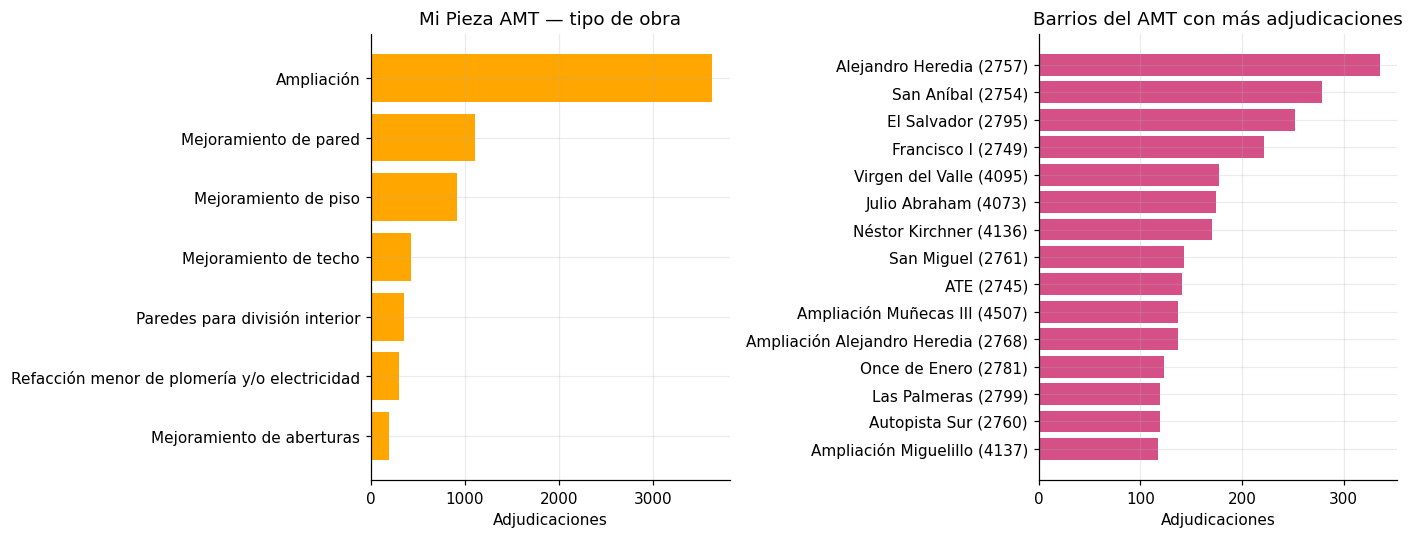

In [1158]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

t = tipos_amt.sort_values()
axes[0].barh(t.index, t.values, color=PAL[5])
axes[0].set_title("Mi Pieza AMT — tipo de obra")
axes[0].set_xlabel("Adjudicaciones")

top_b = (mp_amt_adj.groupby("id_barrio").size().sort_values(ascending=False).head(15))
etiquetas = [f"{NOMBRES_AMT.get(i, i)} ({i})" for i in top_b.index]
axes[1].barh(etiquetas[::-1], top_b.values[::-1], color=PAL[2])
axes[1].set_title("Barrios del AMT con más adjudicaciones")
axes[1].set_xlabel("Adjudicaciones")

plt.tight_layout()
guardar_fig("07_amt_mipieza")
plt.show()

### 7.5 Relación entre las dos políticas en el territorio

Cruce entre obra de integración urbana (colectiva, de infraestructura) y Mi Pieza (individual, de mejoramiento habitacional) a nivel de barrio.

In [1159]:
cruce = pd.DataFrame({"id_renabap": sorted(IDS_AMT)})
cruce["con_obra"] = cruce["id_renabap"].isin(set(obras_amt_barrio["id_renabap"]))
cruce["con_mipieza"] = cruce["id_renabap"].isin(set(mp_amt_adj["id_barrio"]))

matriz = pd.crosstab(cruce["con_obra"], cruce["con_mipieza"])
matriz.index = ["Sin obra", "Con obra"]
matriz.columns = ["Sin Mi Pieza", "Con Mi Pieza"]
guardar_tabla(matriz, "07_amt_cruce_politicas")

print("Barrios del AMT según combinación de intervenciones:\n")
print(matriz)
print(f"\nTotal: {len(cruce)} barrios")

Barrios del AMT según combinación de intervenciones:

          Sin Mi Pieza  Con Mi Pieza
Sin obra            70           103
Con obra             0            41

Total: 214 barrios


---
## 8. Cartografía

Los mapas se construyen con las geometrías reales de los polígonos RENABAP —el archivo nacional trae una columna `WKT` con los `MULTIPOLYGON`—, recortadas al universo AMT y montadas sobre el límite metropolitano de `limite_amt.gpkg`.

Son mapas **de trabajo**: sirven para leer resultados y detectar errores de asignación. La cartografía final de la tesis se sigue armando en QGIS 3.34.13, y para eso la última celda exporta un GeoPackage con toda la clasificación F3 ya incorporada como atributos, listo para simbolizar.

Advertencia sobre el corte: la geometría se toma del relevamiento 2023, que es el más completo. Los barrios que sólo existen en 2018 o 2022 quedan sin polígono y se listan aparte en lugar de desaparecer del mapa sin aviso.

In [1160]:
# --- 8.1 Preparación del entorno geoespacial -----------------------------
try:
    import geopandas as gpd
    from shapely import wkt as _wkt
except ImportError:
    !pip install geopandas --quiet
    import geopandas as gpd
    from shapely import wkt as _wkt

import urllib.request, tempfile, os as _os

CRS_GEO = "EPSG:4326"          # coordenadas originales del RENABAP
CRS_METRICO = "EPSG:5345"      # POSGAR 2007 faja 3 — cálculos métricos en Tucumán
print("geopandas", gpd.__version__)

geopandas 1.1.4


In [1161]:
# --- 8.2 Polígonos de los barrios del AMT --------------------------------
geo23 = leer_csv(f"{RAW}/RENABAP_2023.csv",
                 usecols=["id_renabap", "nombre_barrio", "provincia", "localidad",
                          "cantidad_familias_aproximada", "clasificacion_barrio",
                          "superficie_m2", "WKT"],
                 dtype={"id_renabap": str})
geo23["id_renabap"] = geo23["id_renabap"].str.strip()
geo23 = geo23[geo23["id_renabap"].isin(IDS_AMT)].copy()
geo23["geometry"] = geo23["WKT"].apply(_wkt.loads)

barrios_amt = gpd.GeoDataFrame(geo23.drop(columns=["WKT"]), geometry="geometry", crs=CRS_GEO)

faltantes = IDS_AMT - set(barrios_amt["id_renabap"])
print(f"Barrios con geometría 2023 : {len(barrios_amt)} de {len(IDS_AMT)}")
if faltantes:
    print(f"Sin geometría en el corte 2023: {sorted(faltantes)}")
    print("  (aparecen sólo en 2018 y/o 2022 — no se dibujan)")

Barrios con geometría 2023 : 213 de 214
Sin geometría en el corte 2023: ['2756']
  (aparecen sólo en 2018 y/o 2022 — no se dibujan)


In [1162]:
# --- 8.3 Límite del AMT ---------------------------------------------------
_tmp = _os.path.join(tempfile.gettempdir(), "limite_amt.gpkg")
urllib.request.urlretrieve(f"{RAW}/limite_amt.gpkg", _tmp)
limite_amt = gpd.read_file(_tmp)
if limite_amt.crs is None:
    limite_amt = limite_amt.set_crs(CRS_GEO)
limite_amt = limite_amt.to_crs(CRS_GEO)
print("Límite AMT:", limite_amt.shape, "| CRS:", limite_amt.crs)

Límite AMT: (1, 1) | CRS: EPSG:4326


In [1163]:
# --- 8.4 Atributos de intervención sobre la capa de barrios --------------
obra_por_barrio = (obras_amt_barrio.groupby("id_renabap")
                   .agg(n_proyectos=("proyecto_id", "nunique"),
                        monto=("monto_total", "sum")))
mp_por_barrio_g = mp_amt_adj.groupby("id_barrio").agg(mipieza_adj=("id", "count"),
                                                      mipieza_monto=("monto", "sum"))

# Dimensión predominante por barrio (la más frecuente entre sus proyectos)
dim_barrio = (obras_amt_barrio.groupby("id_renabap")["dimension_principal"]
              .agg(lambda s: s.value_counts().idxmax()))

barrios_amt = (barrios_amt
               .merge(obra_por_barrio, left_on="id_renabap", right_index=True, how="left")
               .merge(mp_por_barrio_g, left_on="id_renabap", right_index=True, how="left")
               .merge(dim_barrio.rename("dimension_predominante"),
                      left_on="id_renabap", right_index=True, how="left"))

for c in ["n_proyectos", "monto", "mipieza_adj", "mipieza_monto"]:
    barrios_amt[c] = barrios_amt[c].fillna(0)

barrios_amt["con_obra"] = barrios_amt["n_proyectos"] > 0
barrios_amt["con_mipieza"] = barrios_amt["mipieza_adj"] > 0
barrios_amt["situacion"] = np.select(
    [barrios_amt["con_obra"] & barrios_amt["con_mipieza"],
     barrios_amt["con_obra"] & ~barrios_amt["con_mipieza"],
     ~barrios_amt["con_obra"] & barrios_amt["con_mipieza"]],
    ["Obra + Mi Pieza", "Sólo obra", "Sólo Mi Pieza"],
    default="Sin intervención")

# Superficie en hectáreas, calculada sobre el CRS métrico
barrios_amt["superficie_ha"] = barrios_amt.to_crs(CRS_METRICO).area / 10_000

print(barrios_amt["situacion"].value_counts())

situacion
Sólo Mi Pieza       103
Sin intervención     70
Obra + Mi Pieza      40
Name: count, dtype: int64


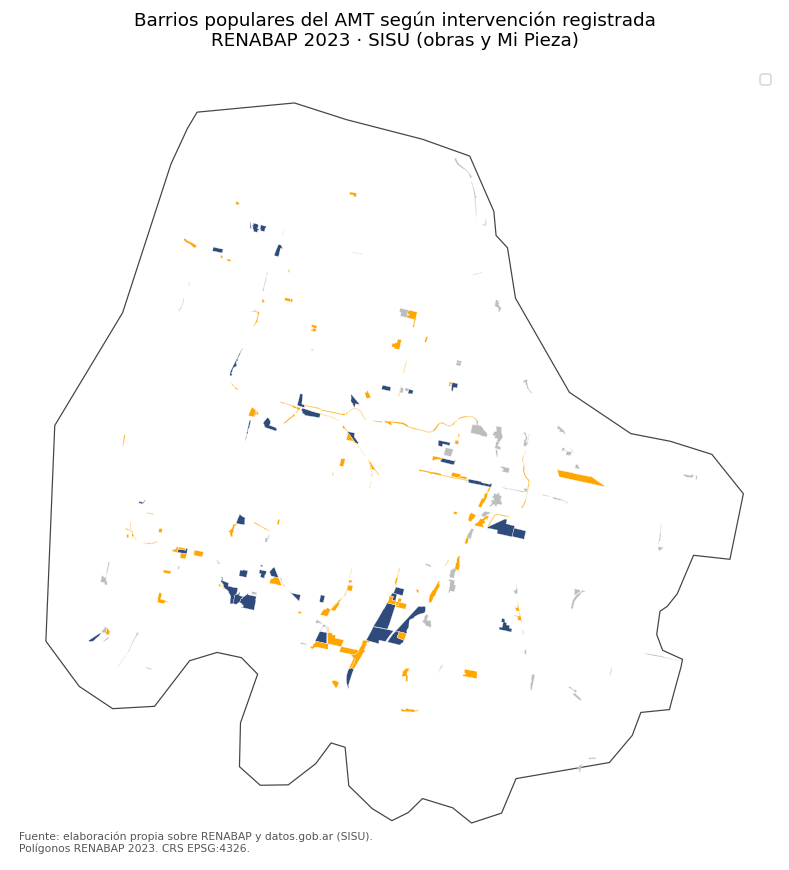

In [1164]:
# --- 8.5 Mapa 1: situación de intervención -------------------------------
COLORES_SIT = {
    "Obra + Mi Pieza": "#2F4B7C",
    "Sólo obra":       "#D45087",
    "Sólo Mi Pieza":   "#FFA600",
    "Sin intervención": "#BDBDBD",
}

fig, ax = plt.subplots(figsize=(9, 10))
limite_amt.boundary.plot(ax=ax, color="#444444", linewidth=0.8, zorder=1)
for sit, color in COLORES_SIT.items():
    sub = barrios_amt[barrios_amt["situacion"] == sit]
    if len(sub):
        sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.2,
                 label=f"{sit} (n={len(sub)})", zorder=2)

ax.set_title("Barrios populares del AMT según intervención registrada\n"
             "RENABAP 2023 · SISU (obras y Mi Pieza)", fontsize=12, pad=14)
ax.legend(loc="upper right", frameon=True, fontsize=9)
ax.set_axis_off()
ax.annotate("Fuente: elaboración propia sobre RENABAP y datos.gob.ar (SISU).\n"
            "Polígonos RENABAP 2023. CRS EPSG:4326.",
            xy=(0.01, 0.01), xycoords="axes fraction", fontsize=7, color="#555555")
guardar_fig("08_mapa_situacion")
plt.show()

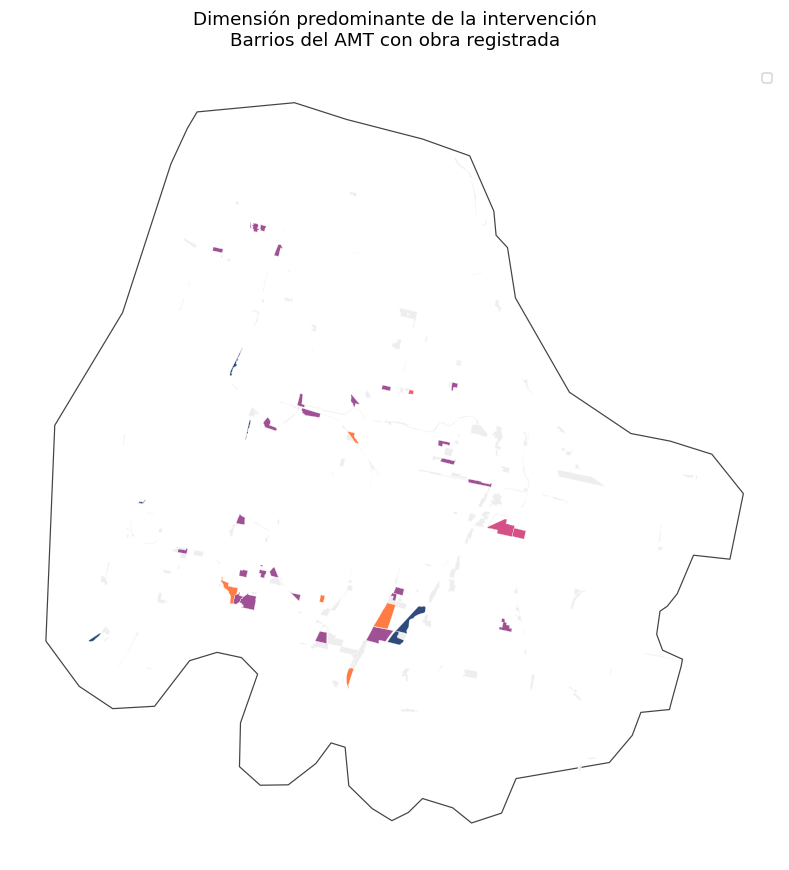

In [1165]:
# --- 8.6 Mapa 2: dimensión predominante de la intervención ---------------
fig, ax = plt.subplots(figsize=(9, 10))
limite_amt.boundary.plot(ax=ax, color="#444444", linewidth=0.8, zorder=1)
barrios_amt[~barrios_amt["con_obra"]].plot(ax=ax, color="#EEEEEE",
                                           edgecolor="white", linewidth=0.2, zorder=2)

con_obra = barrios_amt[barrios_amt["con_obra"]].copy()
dims_presentes = [d for d in con_obra["dimension_predominante"].dropna().unique()]
paleta_dim = {d: PAL[i % len(PAL)] for i, d in enumerate(sorted(dims_presentes))}

for d, color in paleta_dim.items():
    sub = con_obra[con_obra["dimension_predominante"] == d]
    sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.2,
             label=f"{d} (n={len(sub)})", zorder=3)

ax.set_title("Dimensión predominante de la intervención\nBarrios del AMT con obra registrada",
             fontsize=12, pad=14)
ax.legend(loc="upper right", fontsize=8, frameon=True)
ax.set_axis_off()
guardar_fig("08_mapa_dimension")
plt.show()

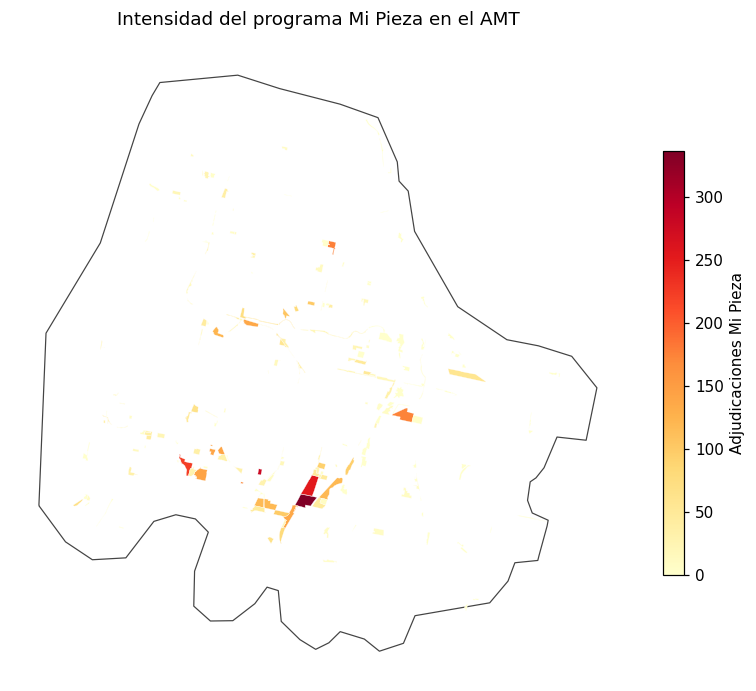

In [1166]:
# --- 8.7 Mapa 3: intensidad de Mi Pieza ----------------------------------
fig, ax = plt.subplots(figsize=(9, 10))
limite_amt.boundary.plot(ax=ax, color="#444444", linewidth=0.8, zorder=1)
barrios_amt.plot(ax=ax, column="mipieza_adj", cmap="YlOrRd", scheme=None,
                 edgecolor="white", linewidth=0.2, legend=True, zorder=2,
                 legend_kwds={"label": "Adjudicaciones Mi Pieza", "shrink": 0.5})
ax.set_title("Intensidad del programa Mi Pieza en el AMT", fontsize=12, pad=14)
ax.set_axis_off()
guardar_fig("08_mapa_mipieza")
plt.show()

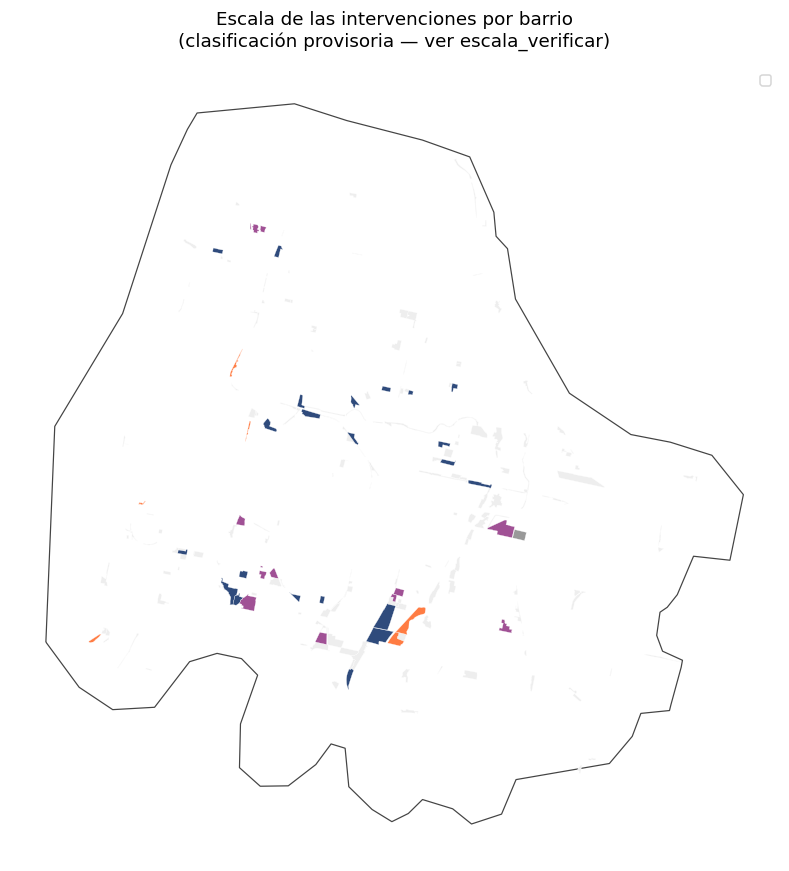

In [1167]:
# --- 8.8 Mapa 4: escala declarada de las intervenciones ------------------
escala_barrio = (obras_amt_barrio.groupby("id_renabap")["escala"]
                 .agg(lambda s: "ambas" if s.nunique() > 1 else s.iloc[0]))
barrios_amt = barrios_amt.merge(escala_barrio.rename("escala_barrio"),
                                left_on="id_renabap", right_index=True, how="left")

COLORES_ESC = {"barrial": "#2F4B7C", "comunitaria": "#FF7C43",
               "ambas": "#A05195", "sin determinar": "#999999"}

fig, ax = plt.subplots(figsize=(9, 10))
limite_amt.boundary.plot(ax=ax, color="#444444", linewidth=0.8, zorder=1)
barrios_amt[barrios_amt["escala_barrio"].isna()].plot(
    ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.2, zorder=2)
for esc, color in COLORES_ESC.items():
    sub = barrios_amt[barrios_amt["escala_barrio"] == esc]
    if len(sub):
        sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.2,
                 label=f"{esc} (n={len(sub)})", zorder=3)

ax.set_title("Escala de las intervenciones por barrio\n(clasificación provisoria — ver escala_verificar)",
             fontsize=12, pad=14)
ax.legend(loc="upper right", fontsize=9, frameon=True)
ax.set_axis_off()
guardar_fig("08_mapa_escala")
plt.show()

In [1168]:
# --- 8.9 Exportación para QGIS 3.34.13 -----------------------------------
# GeoPackage con la clasificación F3 como atributos. Los campos booleanos se
# convierten a entero porque QGIS los simboliza mejor así.
salida_gpkg = "salidas/barrios_amt_intervenciones.gpkg"

exportar = barrios_amt.copy()
for c in exportar.columns:
    if exportar[c].dtype == bool:
        exportar[c] = exportar[c].astype(int)

if EXPORTAR:
    exportar.to_file(salida_gpkg, layer="barrios_amt", driver="GPKG")
    # Capa de proyectos con su clasificación, unida por id_renabap
    proy_geo = (obras_amt_barrio
                .merge(barrios_amt[["id_renabap", "geometry"]], on="id_renabap", how="left"))
    proy_geo = gpd.GeoDataFrame(proy_geo, geometry="geometry", crs=CRS_GEO)
    proy_geo = proy_geo.drop(columns=[c for c in proy_geo.columns
                                      if proy_geo[c].dtype == object
                                      and proy_geo[c].map(type).eq(list).any()])
    for c in proy_geo.columns:
        if proy_geo[c].dtype == bool:
            proy_geo[c] = proy_geo[c].astype(int)
    proy_geo.to_file(salida_gpkg, layer="proyectos_amt", driver="GPKG")
    print(f"GeoPackage exportado: {salida_gpkg}")
    print("  capas: barrios_amt · proyectos_amt")
    print(f"  CRS: {CRS_GEO} — reproyectar a {CRS_METRICO} en QGIS para cálculos métricos")

GeoPackage exportado: salidas/barrios_amt_intervenciones.gpkg
  capas: barrios_amt · proyectos_amt
  CRS: EPSG:4326 — reproyectar a EPSG:5345 en QGIS para cálculos métricos


---
## 9. Exportación

Todas las tablas quedan en `salidas/tablas/` y las figuras en `salidas/figuras/`. La celda siguiente comprime todo para descargar desde Colab.

In [1169]:
import shutil
shutil.make_archive("salidas_bloque2", "zip", "salidas")
print("Archivo generado: salidas_bloque2.zip")

# En Colab, descomentar para descargar:
# from google.colab import files
# files.download("salidas_bloque2.zip")

Archivo generado: salidas_bloque2.zip


In [1170]:
# Bases armonizadas, por si se quieren retomar en otro cuaderno o llevar a QGIS
if EXPORTAR:
    obras.drop(columns=["ids_renabap"]).to_csv("salidas/obras_armonizadas.csv", index=False, encoding="utf-8-sig")
    obras_barrio.drop(columns=["ids_renabap"], errors="ignore").to_csv("salidas/obras_por_barrio.csv", index=False, encoding="utf-8-sig")
    obras_amt.drop(columns=["ids_renabap"]).to_csv("salidas/obras_amt.csv", index=False, encoding="utf-8-sig")
    det_barrio.to_csv("salidas/amt_detalle_barrio.csv", encoding="utf-8-sig")
    print("Bases exportadas.")

Bases exportadas.


---
## 10. Pendientes de calibración

1. **Escala.** El `escala_verificar = True` marca los proyectos cuya escala se infirió del valor por defecto de la subdimensión y no de una expresión diagnóstica. Es la lista de trabajo para cotejar con expedientes, entrevistas o imagen satelital.
2. **Vivienda y las matrices.** Definir si el mejoramiento habitacional entra en la dimensión "Entorno y vivienda" o si las matrices se declaran explícitamente circunscriptas al entorno. Mientras tanto figura como `Vivienda (fuera de matriz)`.
3. **Genéricos.** Los proyectos "Obras de Integración Socio Urbana" quedan como `sin_especificar`. La celda 4 muestra cuántos podrían imputarse desde el Monitor; la imputación no está aplicada.
4. **`MUNICIPIOS_AMT`.** Ajustar la lista a la delimitación efectiva de `limite_amt.gpkg`. Lules y San Isidro de Lules ya están unificados en `municipio_amt`.
5. **ICC.** Si la descarga automática falla, cargar la serie a mano y volver a correr la celda 3.6. Verificar además que `MES_BASE_ICC` sea el mes al que querés referir todos los montos.
6. **Barrios sin geometría 2023.** Los que sólo aparecen en 2018 o 2022 no se dibujan en los mapas; si son relevantes, hay que recuperar sus polígonos del archivo nacional correspondiente.